<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 45px 35px; border-radius: 15px; text-align: center; margin-bottom: 10px;">
  <h1 style="color: #e94560; font-size: 2.8em; margin: 0; font-weight: 900; letter-spacing: 2px;">🧠 GLOBAL MENTAL HEALTH</h1>
  <h2 style="color: #a8dadc; font-size: 1.5em; margin: 10px 0 5px; font-weight: 400;">Crisis Index — Deep Analysis & Machine Learning</h2>
  <p style="color: #457b9d; font-size: 1em; margin: 0;">2015 – 2024 · 39 Countries · 6 Regions · 1,100 Records · 24 Features</p>
  <hr style="border: 1px solid #e94560; width: 60%; margin: 20px auto;">
  <p style="color: #a8dadc; font-size: 0.95em; margin: 0; font-style: italic;">"Mental health is not a destination, but a process. It's about how you drive, not where you're going." — Noam Shpancer</p>
</div>

---
## 📋 Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | 📦 Setup & Libraries | Import packages and configure styling |
| 2 | 📂 Load & Inspect | Shape, dtypes, missing values, statistics |
| 3 | 🌍 Global Crisis Overview | Crisis index distribution and crisis levels |
| 4 | 🏥 Disorder Deep Dive | Depression, anxiety, suicide & all 7 disorders |
| 5 | 🗺️ Geographic Analysis | Regional & income-level breakdowns |
| 6 | 📅 Time Trends | Year-over-year mental health evolution |
| 7 | 🔗 Correlation & Heatmap | Feature relationships & drivers |
| 8 | 🩺 Healthcare System | Treatment gap, psychiatrists, spending |
| 9 | 🌐 Social Factors | Screen time, unemployment, stigma, support |
| 10 | 🤖 ML — Classification | Predict crisis level (Random Forest + XGBoost) |
| 11 | 📈 ML — Regression | Predict Mental Health Crisis Index score |
| 12 | 🧩 Clustering | K-Means country grouping by mental health profile |
| 13 | 📌 Key Takeaways | Summary of all findings |

---

<div style="background:#fff3cd; border-left:5px solid #ffc107; padding:15px 20px; border-radius:5px; margin:10px 0;">
  <h3 style="margin:0 0 8px; color:#856404;">⚠️ Dataset Note</h3>
  <p style="margin:0; color:#856404;">This is a <strong>synthetically generated but statistically realistic</strong> mental health dataset. All rates are calibrated to match real-world WHO, IHME, and Our World in Data distributions. Designed for <strong>education, research, and machine learning</strong>.</p>
</div>

---
## 1. 📦 Setup & Libraries

In [7]:
# ── Core ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

# ── Machine Learning ──────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,
                              mean_squared_error, r2_score, mean_absolute_error)
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# ── Style ─────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor': '#ffffff',
})

CRISIS_COLORS = {'Low':'#2ecc71', 'Moderate':'#f1c40f', 'High':'#e67e22', 'Severe':'#e74c3c'}
REGION_COLORS = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c']

print('✅ All libraries loaded!')
print('🧠 Ready to explore the Global Mental Health Crisis Index dataset.')

✅ All libraries loaded!
🧠 Ready to explore the Global Mental Health Crisis Index dataset.


---
## 2. 📂 Load & Inspect the Dataset

> We begin with a thorough inspection — shape, dtypes, missing values, and descriptive statistics across all 24 features.

In [8]:
import os
df = pd.read_csv(r'D:\Downloadsss\global_mental_health_crisis_index.csv', parse_dates=['Year'])


print('=' * 60)
print('   🧠 GLOBAL MENTAL HEALTH CRISIS INDEX — OVERVIEW')
print('=' * 60)
print(f'  🗂️  Total Records        : {df.shape[0]:,}')
print(f'  📊  Total Features       : {df.shape[1]}')
print(f'  🌍  Countries            : {df["Country"].nunique()}')
print(f'  🗺️  Regions              : {df["Region"].nunique()}')
print(f'  📅  Year Range           : {df["Year"].min()} – {df["Year"].max()}')
print(f'  📈  Max Crisis Index     : {df["Mental_Health_Crisis_Index"].max()}')
print(f'  📉  Min Crisis Index     : {df["Mental_Health_Crisis_Index"].min()}')
print(f'  📊  Mean Crisis Index    : {df["Mental_Health_Crisis_Index"].mean():.2f}')
print(f'  🔴  Suicide Rate Max     : {df["Suicide_Rate_Per_100k"].max()} per 100k')
print(f'  🩺  Treatment Gap Max    : {df["Treatment_Gap_Pct"].max()}%')
print('=' * 60)
df.head()

   🧠 GLOBAL MENTAL HEALTH CRISIS INDEX — OVERVIEW
  🗂️  Total Records        : 1,100
  📊  Total Features       : 24
  🌍  Countries            : 39
  🗺️  Regions              : 6
  📅  Year Range           : 2015-01-01 00:00:00 – 2024-01-01 00:00:00
  📈  Max Crisis Index     : 73.91
  📉  Min Crisis Index     : 34.93
  📊  Mean Crisis Index    : 55.12
  🔴  Suicide Rate Max     : 17.99 per 100k
  🩺  Treatment Gap Max    : 97.9%


,Record_ID,Year,Country,Region,Income_Level,Depression_Rate_Pct,Anxiety_Rate_Pct,Bipolar_Disorder_Rate_Pct,Schizophrenia_Rate_Pct,PTSD_Rate_Pct,...,Healthcare_Access_Index,Psychiatrists_Per_100k,Govt_MentalHealth_Spending_PctGDP,Avg_Daily_Screen_Time_Hours,Unemployment_Rate_Pct,Urbanization_Rate_Pct,Social_Support_Index,Stigma_Index,Mental_Health_Crisis_Index,Crisis_Level
0,GMHCI-0001,2021-01-01,Vietnam,Asia,Lower-Middle,9.38,9.39,0.64,1.191,1.05,...,44.2,1.17,1.10,6.0,14.8,92.8,49.7,65.3,56.65,High
1,GMHCI-0002,2024-01-01,Netherlands,Europe,High,13.24,11.12,2.98,0.422,6.16,...,85.5,12.97,10.53,3.8,5.7,40.5,55.7,6.1,53.33,High
2,GMHCI-0003,2018-01-01,Poland,Europe,Upper-Middle,8.12,8.07,0.63,0.725,6.12,...,50.0,9.43,4.17,5.0,27.2,59.0,39.8,51.0,59.20,High
3,GMHCI-0004,2017-01-01,Russia,Europe,Upper-Middle,9.40,10.04,3.05,0.279,4.28,...,70.1,5.46,4.86,8.6,18.6,40.0,42.0,23.1,60.37,High
4,GMHCI-0005,2019-01-01,Colombia,South America,Upper-Middle,8.74,15.19,2.58,1.027,8.35,...,54.4,2.39,5.50,7.4,15.4,77.6,81.7,40.3,63.94,High


In [9]:
# ── Data Types & Missing Values ────────────────────────────────────
print('📋 Data Types:')
print(df.dtypes)
print('\n🔍 Missing Values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else '✅ No missing values — dataset is complete!')

📋 Data Types:
Record_ID                                       str
Year                                 datetime64[us]
Country                                         str
Region                                          str
Income_Level                                    str
Depression_Rate_Pct                         float64
Anxiety_Rate_Pct                            float64
Bipolar_Disorder_Rate_Pct                   float64
Schizophrenia_Rate_Pct                      float64
PTSD_Rate_Pct                               float64
Eating_Disorder_Rate_Pct                    float64
Substance_Use_Disorder_Pct                  float64
Suicide_Rate_Per_100k                       float64
Treatment_Gap_Pct                           float64
Healthcare_Access_Index                     float64
Psychiatrists_Per_100k                      float64
Govt_MentalHealth_Spending_PctGDP           float64
Avg_Daily_Screen_Time_Hours                 float64
Unemployment_Rate_Pct                       float6

In [10]:
# ── Descriptive Statistics ─────────────────────────────────────────
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print('📊 Full Statistical Summary:')
df[numeric_cols].describe().round(3)

📊 Full Statistical Summary:


,Depression_Rate_Pct,Anxiety_Rate_Pct,Bipolar_Disorder_Rate_Pct,Schizophrenia_Rate_Pct,PTSD_Rate_Pct,Eating_Disorder_Rate_Pct,Substance_Use_Disorder_Pct,Suicide_Rate_Per_100k,Treatment_Gap_Pct,Healthcare_Access_Index,Psychiatrists_Per_100k,Govt_MentalHealth_Spending_PctGDP,Avg_Daily_Screen_Time_Hours,Unemployment_Rate_Pct,Urbanization_Rate_Pct,Social_Support_Index,Stigma_Index,Mental_Health_Crisis_Index
count,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000,1100.000
mean,10.770,12.921,1.982,0.705,5.025,2.292,7.058,9.735,58.963,61.095,8.666,4.792,7.063,15.125,61.453,57.341,39.133,55.120
std,3.485,4.238,0.845,0.289,2.327,0.992,2.958,3.727,18.528,23.005,7.476,3.213,2.350,7.562,20.796,21.604,23.386,7.171
min,3.690,4.070,0.500,0.200,1.010,0.500,1.510,2.450,25.000,5.800,0.030,0.120,3.000,2.000,25.000,20.000,0.000,34.930
25%,8.185,10.188,1.250,0.462,3.080,1.440,4.560,6.660,43.400,43.275,1.628,2.070,5.075,8.400,43.300,38.775,20.175,49.878
50%,10.485,12.375,2.010,0.712,5.015,2.330,7.105,9.500,59.250,63.450,7.280,4.385,7.100,15.100,61.650,57.450,37.400,55.010
75%,13.482,16.032,2.660,0.953,6.990,3.140,9.550,12.342,74.100,80.200,14.420,6.892,9.100,21.800,78.500,76.500,57.300,59.998
max,17.990,22.000,3.500,1.199,9.000,4.000,12.000,17.990,97.900,97.900,24.960,11.990,11.000,27.900,98.000,95.000,98.500,73.910


In [11]:
# ── Categorical Distributions ──────────────────────────────────────
print('🌍 Region Distribution:')
print(df['Region'].value_counts().to_string())
print('\n💰 Income Level Distribution:')
print(df['Income_Level'].value_counts().to_string())
print('\n🚨 Crisis Level Distribution:')
print(df['Crisis_Level'].value_counts().to_string())

🌍 Region Distribution:
Region
Asia             359
Europe           324
Africa           161
South America    105
North America     92
Oceania           59

💰 Income Level Distribution:
Income_Level
High            427
Upper-Middle    340
Lower-Middle    299
Low              34

🚨 Crisis Level Distribution:
Crisis_Level
High        817
Moderate    283


---
## 3. 🌍 Global Crisis Overview

> The **Mental Health Crisis Index (MHCI)** is a composite score (0–100) derived from depression rate, anxiety rate, suicide rate, treatment gap, and stigma index. Higher scores indicate worse mental health outcomes.

| MHCI Range | Crisis Level | Meaning |
|------------|-------------|-------------------------------|
| 0 – 24 | 🟢 Low | Manageable mental health burden |
| 25 – 49 | 🟡 Moderate | Significant burden, action needed |
| 50 – 74 | 🟠 High | Serious crisis, urgent investment |
| 75 – 100 | 🔴 Severe | Emergency — systemic collapse |

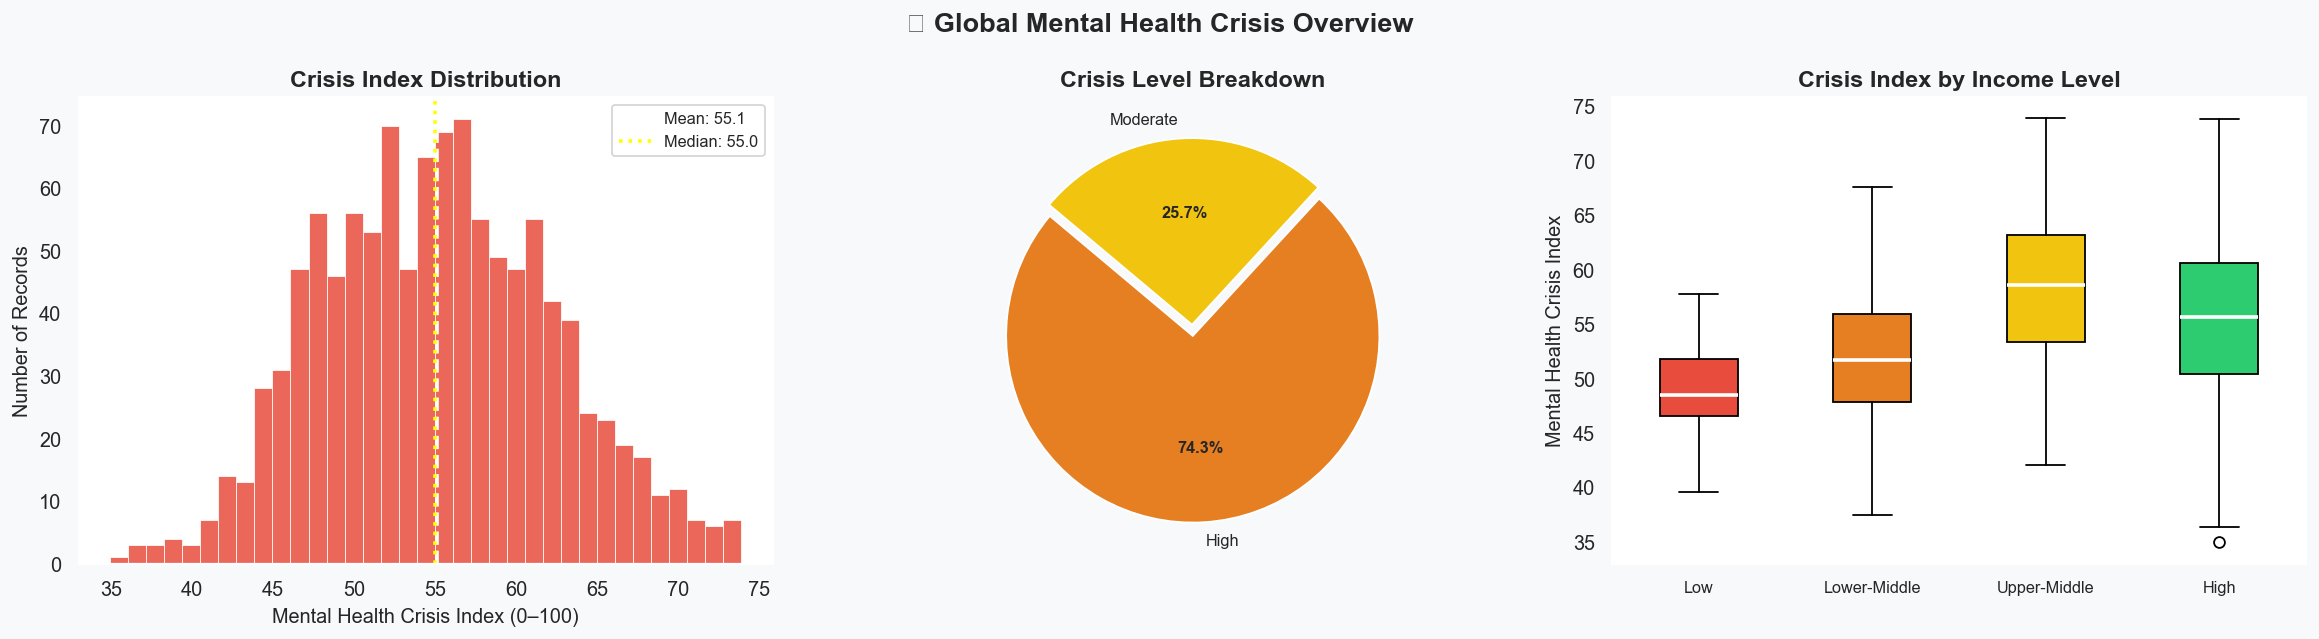

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🌍 Global Mental Health Crisis Overview', fontsize=15, fontweight='bold')

# ── MHCI Distribution ─────────────────────────────────────────────
axes[0].hist(df['Mental_Health_Crisis_Index'], bins=35, edgecolor='white', linewidth=0.5, color='#e74c3c', alpha=0.85)
axes[0].axvline(df['Mental_Health_Crisis_Index'].mean(), color='white', linewidth=2,
                linestyle='--', label=f'Mean: {df["Mental_Health_Crisis_Index"].mean():.1f}')
axes[0].axvline(df['Mental_Health_Crisis_Index'].median(), color='yellow', linewidth=2,
                linestyle=':', label=f'Median: {df["Mental_Health_Crisis_Index"].median():.1f}')
axes[0].set_title('Crisis Index Distribution')
axes[0].set_xlabel('Mental Health Crisis Index (0–100)')
axes[0].set_ylabel('Number of Records')
axes[0].legend(fontsize=9)

# ── Crisis Level Pie ──────────────────────────────────────────────
cl = df['Crisis_Level'].value_counts()
pie_colors = [CRISIS_COLORS.get(k, '#ccc') for k in cl.index]
wedges, texts, autos = axes[1].pie(
    cl, labels=cl.index, autopct='%1.1f%%',
    colors=pie_colors, startangle=140,
    explode=[0.03]*len(cl), textprops={'fontsize': 9}
)
for a in autos: a.set_fontweight('bold')
axes[1].set_title('Crisis Level Breakdown')

# ── Box Plot by Income Level ──────────────────────────────────────
income_order = ['Low','Lower-Middle','Upper-Middle','High']
data_by_income = [df[df['Income_Level']==il]['Mental_Health_Crisis_Index'].values for il in income_order]
bp = axes[2].boxplot(data_by_income, patch_artist=True,
                     medianprops={'color':'white','linewidth':2})
box_c = ['#e74c3c','#e67e22','#f1c40f','#2ecc71']
for patch, c in zip(bp['boxes'], box_c): patch.set_facecolor(c)
axes[2].set_xticklabels(income_order, fontsize=9)
axes[2].set_title('Crisis Index by Income Level')
axes[2].set_ylabel('Mental Health Crisis Index')

plt.tight_layout()
plt.show()

---
## 4. 🏥 Mental Disorder Deep Dive

> Exploring all **7 mental disorders** tracked in this dataset — their prevalence rates, distributions, and how they compare across crisis levels.

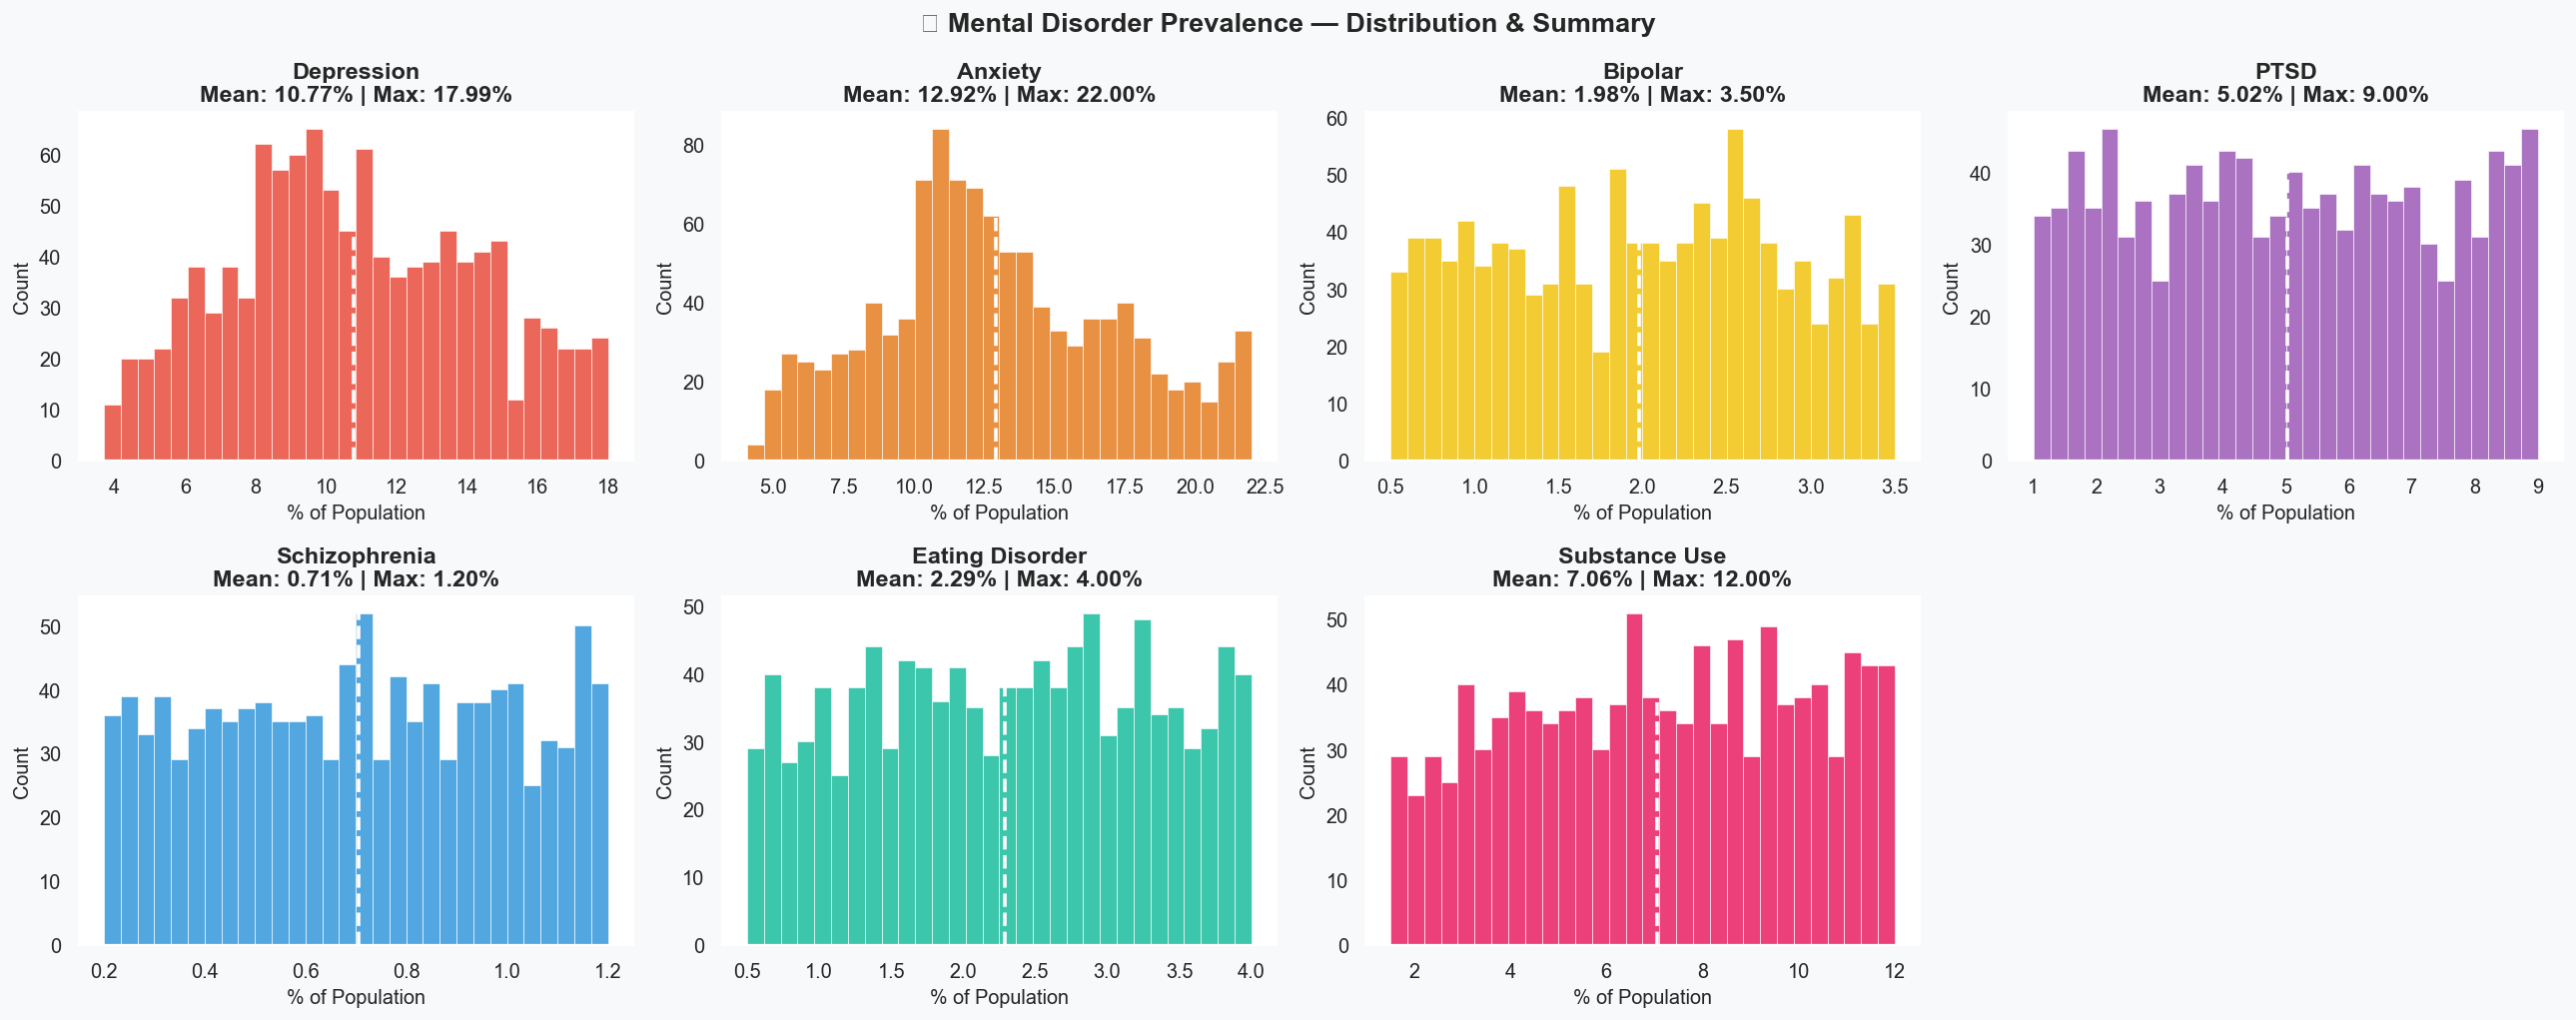

In [13]:
disorders = [
    ('Depression_Rate_Pct', 'Depression', '#e74c3c'),
    ('Anxiety_Rate_Pct', 'Anxiety', '#e67e22'),
    ('Bipolar_Disorder_Rate_Pct', 'Bipolar', '#f1c40f'),
    ('PTSD_Rate_Pct', 'PTSD', '#9b59b6'),
    ('Schizophrenia_Rate_Pct', 'Schizophrenia', '#3498db'),
    ('Eating_Disorder_Rate_Pct', 'Eating Disorder', '#1abc9c'),
    ('Substance_Use_Disorder_Pct', 'Substance Use', '#e91e63'),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('🏥 Mental Disorder Prevalence — Distribution & Summary', fontsize=15, fontweight='bold')
axes = axes.flatten()

for idx, (col, label, color) in enumerate(disorders):
    axes[idx].hist(df[col], bins=30, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    axes[idx].axvline(df[col].mean(), color='white', linewidth=2, linestyle='--')
    axes[idx].set_title(f'{label}\nMean: {df[col].mean():.2f}% | Max: {df[col].max():.2f}%')
    axes[idx].set_xlabel('% of Population')
    axes[idx].set_ylabel('Count')

axes[7].axis('off')

plt.tight_layout()
plt.show()

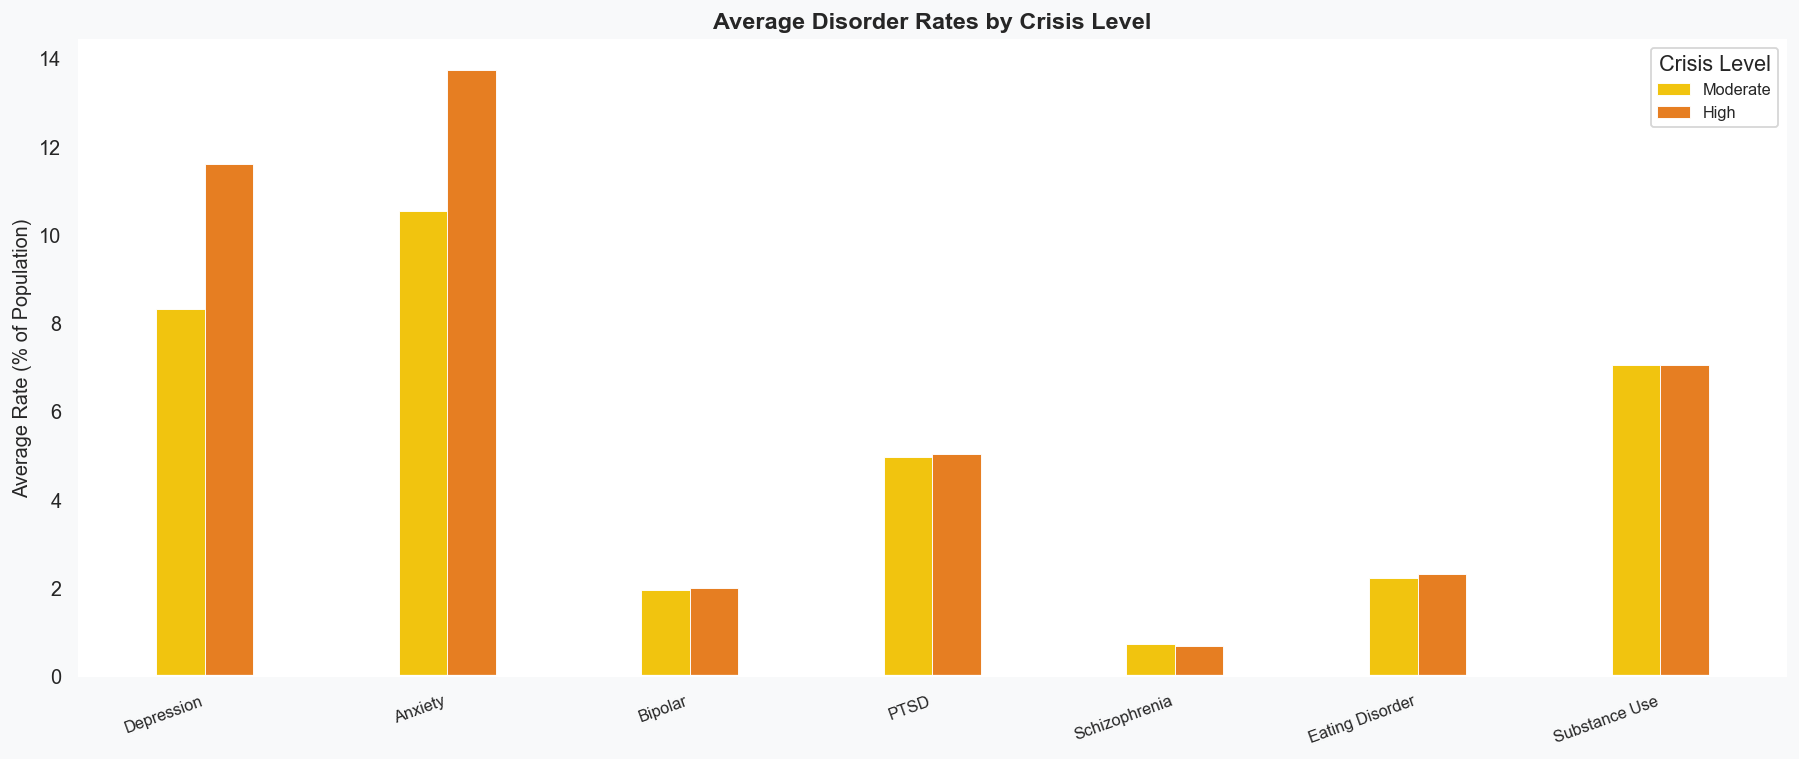

In [14]:
# ── Disorder Rates by Crisis Level ────────────────────────────────
disorder_cols = [d[0] for d in disorders]
disorder_labels = [d[1] for d in disorders]

crisis_order = ['Low','Moderate','High','Severe']
crisis_means = df.groupby('Crisis_Level')[disorder_cols].mean().reindex(
    [c for c in crisis_order if c in df['Crisis_Level'].unique()])

crisis_means.columns = disorder_labels
crisis_means_t = crisis_means.T

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(disorder_labels))
width = 0.2
colors = [CRISIS_COLORS[c] for c in crisis_means_t.columns]

for i, (col, color) in enumerate(zip(crisis_means_t.columns, colors)):
    ax.bar(x + i*width, crisis_means_t[col], width, label=col, color=color,
           edgecolor='white', linewidth=0.5)

ax.set_xticks(x + width * (len(crisis_means_t.columns)-1)/2)
ax.set_xticklabels(disorder_labels, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Average Rate (% of Population)')
ax.set_title('Average Disorder Rates by Crisis Level', fontsize=13, fontweight='bold')
ax.legend(title='Crisis Level', fontsize=9)
plt.tight_layout()
plt.show()

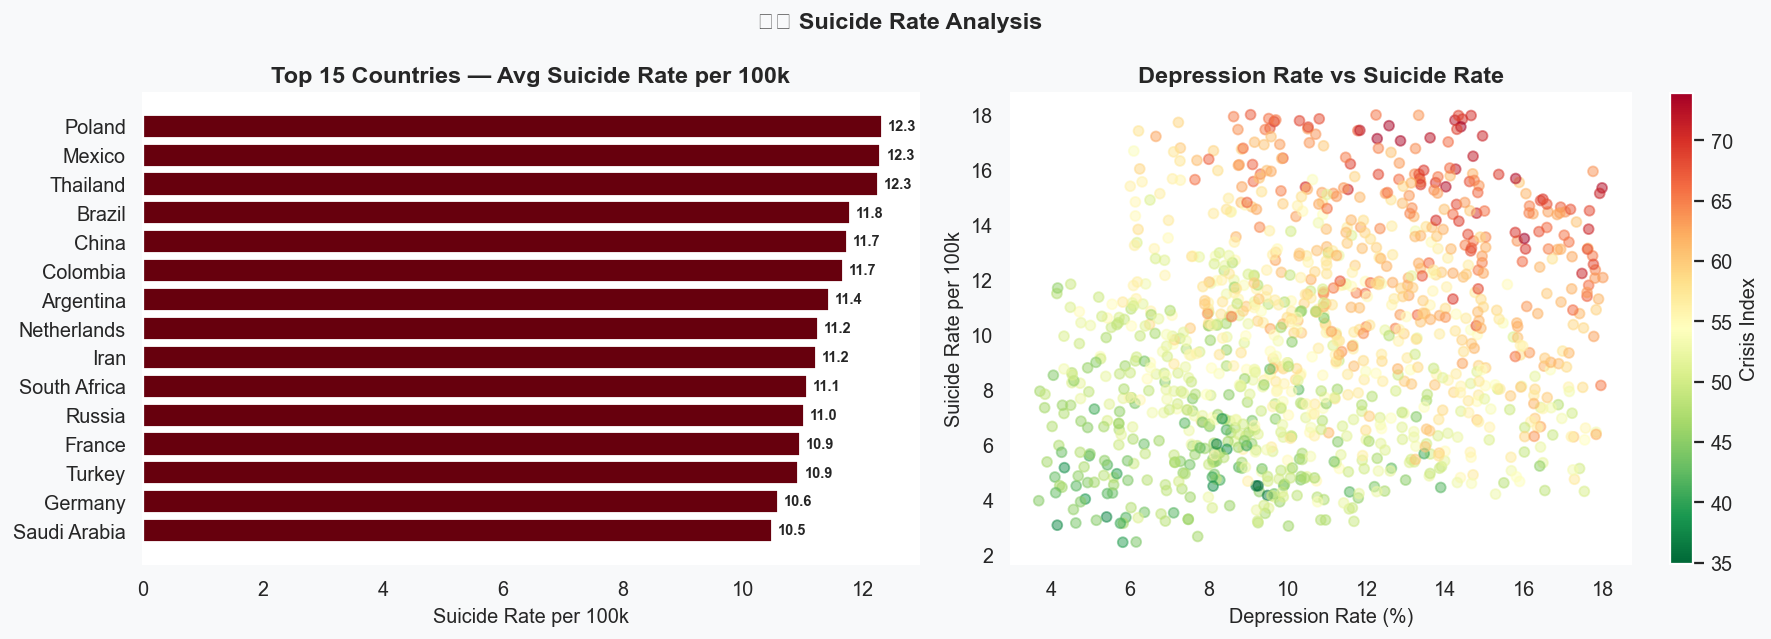

In [15]:
# ── Suicide Rate Deep Dive ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('☠️ Suicide Rate Analysis', fontsize=13, fontweight='bold')

top_sui = df.groupby('Country')['Suicide_Rate_Per_100k'].mean().sort_values(ascending=False).head(15)
norm = top_sui / top_sui.max()
axes[0].barh(top_sui.index, top_sui.values,
             color=plt.cm.Reds(norm + 0.2), edgecolor='white')
for i, v in enumerate(top_sui.values):
    axes[0].text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=8, fontweight='bold')
axes[0].set_title('Top 15 Countries — Avg Suicide Rate per 100k')
axes[0].set_xlabel('Suicide Rate per 100k')
axes[0].invert_yaxis()

axes[1].scatter(df['Depression_Rate_Pct'], df['Suicide_Rate_Per_100k'],
                c=df['Mental_Health_Crisis_Index'], cmap='RdYlGn_r',
                alpha=0.5, s=30)
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r')
sm.set_array(df['Mental_Health_Crisis_Index'])
plt.colorbar(sm, ax=axes[1], label='Crisis Index')
axes[1].set_xlabel('Depression Rate (%)')
axes[1].set_ylabel('Suicide Rate per 100k')
axes[1].set_title('Depression Rate vs Suicide Rate')

plt.tight_layout()
plt.show()

---
## 5. 🗺️ Geographic Analysis

> How does the mental health crisis vary across **regions** and **income levels**? Understanding geography is key to targeting interventions.

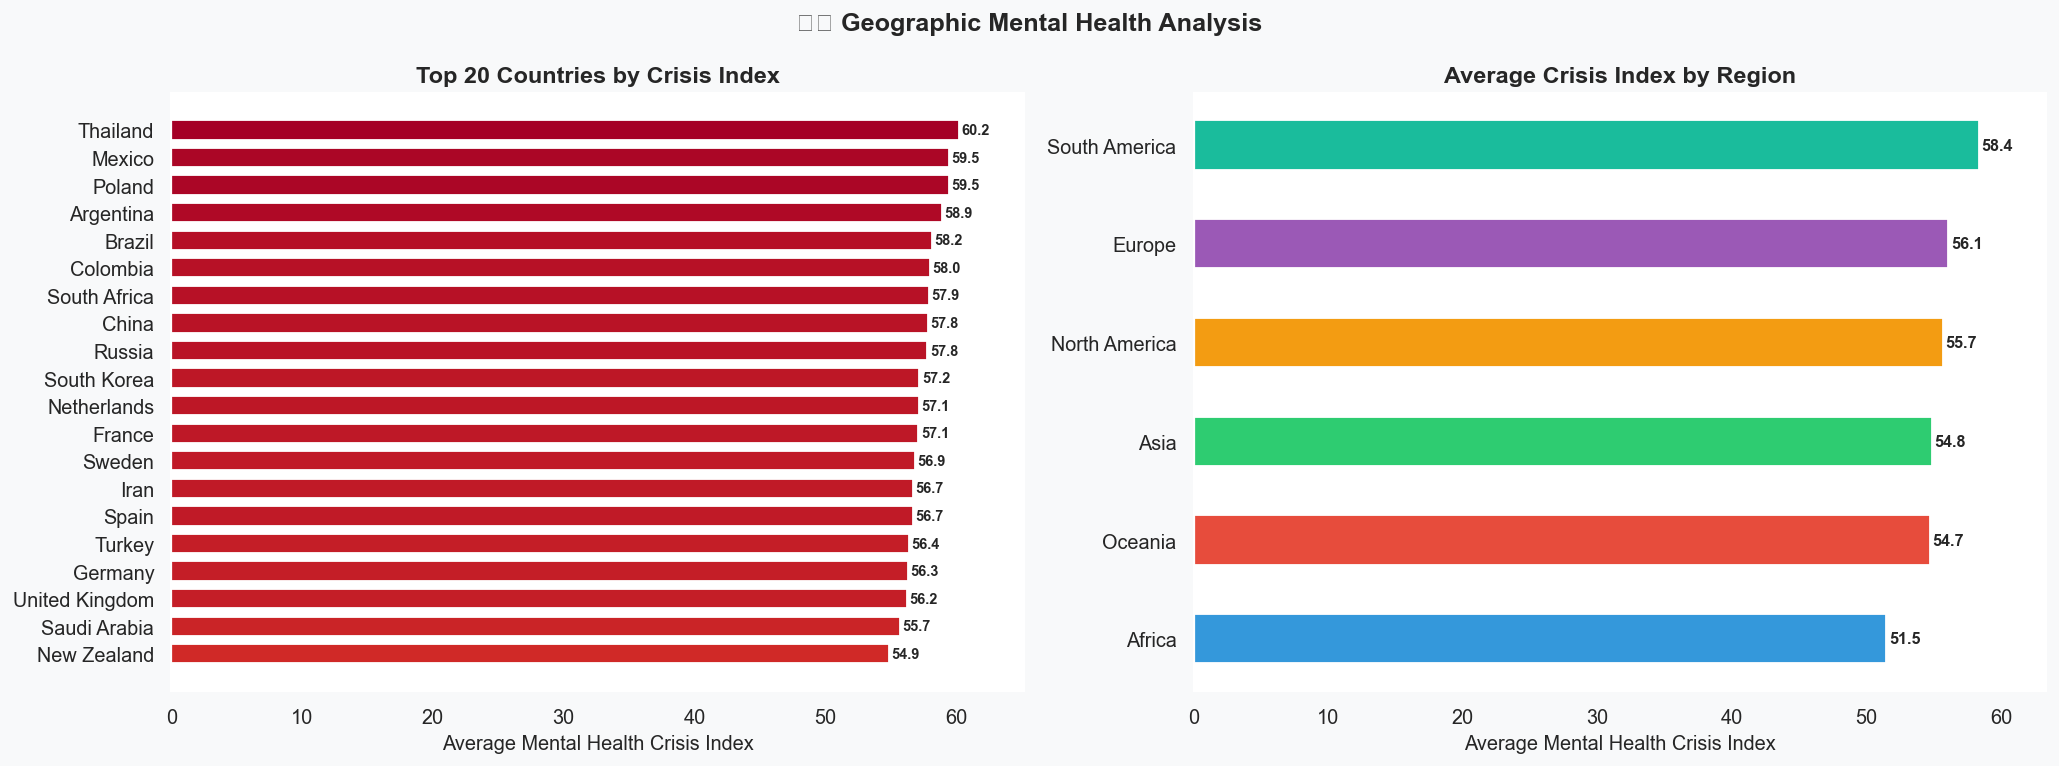

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🗺️ Geographic Mental Health Analysis', fontsize=14, fontweight='bold')

# ── Average MHCI by Country (top 20) ─────────────────────────────
country_mhci = df.groupby('Country')['Mental_Health_Crisis_Index'].mean().sort_values(ascending=False).head(20)
norm = country_mhci / country_mhci.max()
axes[0].barh(country_mhci.index, country_mhci.values,
             color=plt.cm.RdYlGn_r(norm), edgecolor='white', height=0.7)
for i, v in enumerate(country_mhci.values):
    axes[0].text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=8, fontweight='bold')
axes[0].set_title('Top 20 Countries by Crisis Index')
axes[0].set_xlabel('Average Mental Health Crisis Index')
axes[0].invert_yaxis()
axes[0].set_xlim(0, country_mhci.max() + 5)

# ── Average MHCI by Region ────────────────────────────────────────
region_mhci = df.groupby('Region')['Mental_Health_Crisis_Index'].mean().sort_values(ascending=True)
axes[1].barh(region_mhci.index, region_mhci.values,
             color=REGION_COLORS[:len(region_mhci)], edgecolor='white', height=0.5)
for i, v in enumerate(region_mhci.values):
    axes[1].text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Average Crisis Index by Region')
axes[1].set_xlabel('Average Mental Health Crisis Index')
axes[1].set_xlim(0, region_mhci.max() + 5)

plt.tight_layout()
plt.show()

📊 Average Key Indicators by Region:
               Depression_Rate_Pct  Anxiety_Rate_Pct  Suicide_Rate_Per_100k  Treatment_Gap_Pct
Region                                                                                        
Africa                        7.65              9.22                   7.57              79.21
Asia                         10.14             11.89                   9.49              64.28
Europe                       12.22             14.77                  10.26              48.83
North America                12.17             15.00                  10.34              48.04
Oceania                      12.90             16.36                   9.92              38.30
South America                10.83             12.68                  11.63              62.20


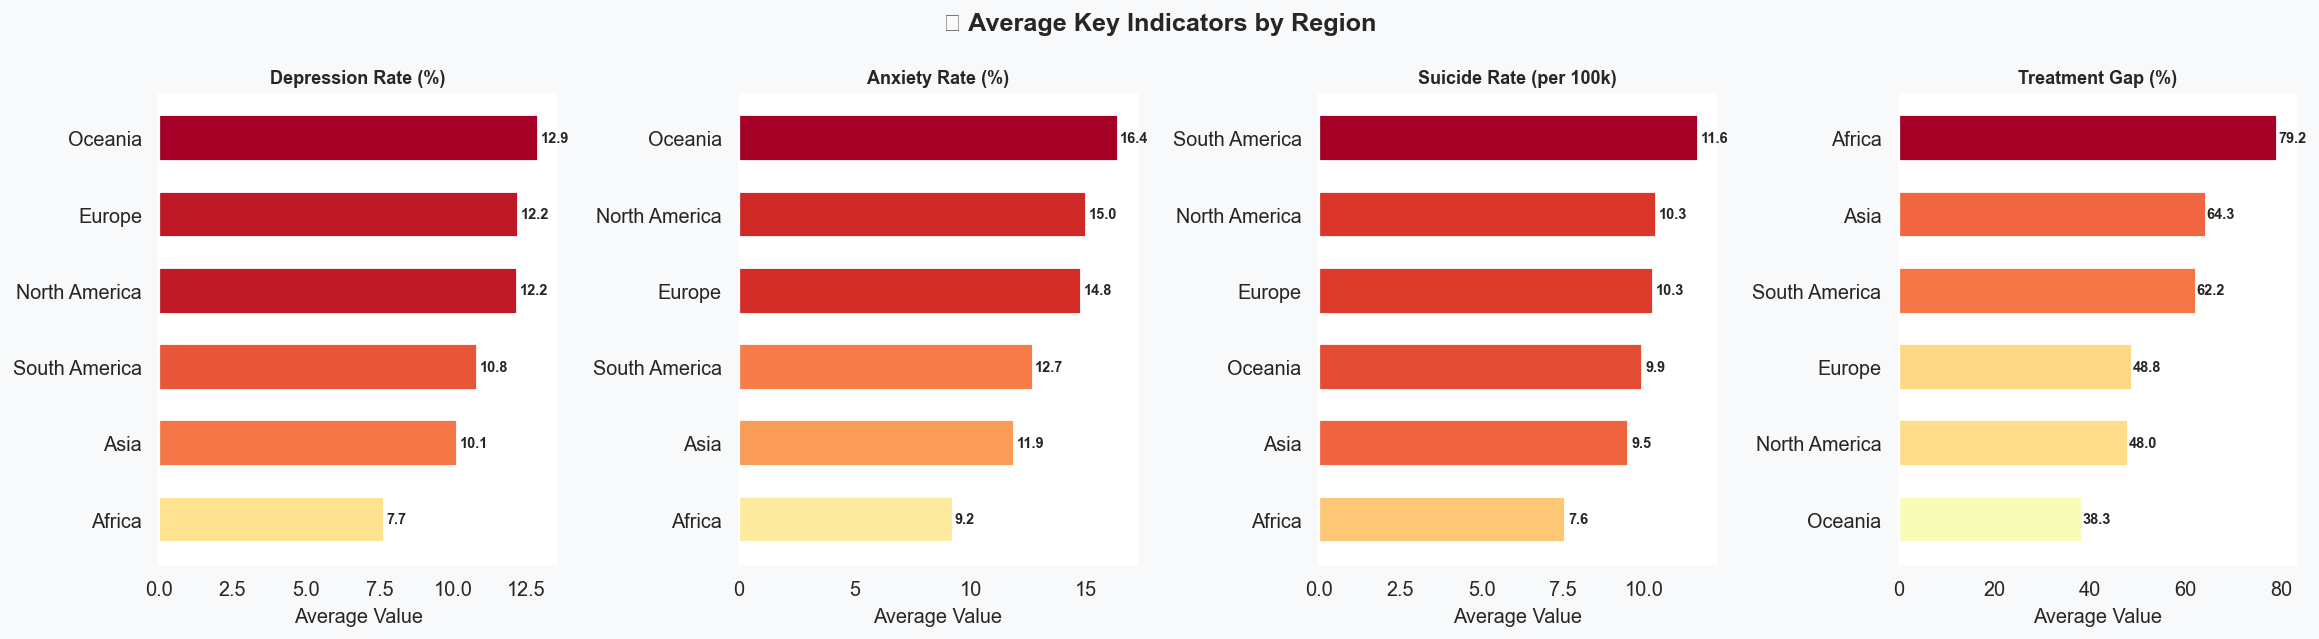

In [18]:
# ── Grouped disorder comparison by Region ─────────────────────────
region_disorders = df.groupby('Region')[['Depression_Rate_Pct','Anxiety_Rate_Pct',
                                          'Suicide_Rate_Per_100k','Treatment_Gap_Pct']].mean().round(2)

print('📊 Average Key Indicators by Region:')
print(region_disorders.to_string())

# ── Visual bar chart instead of styled table ──────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('📊 Average Key Indicators by Region', fontsize=14, fontweight='bold')

cols = ['Depression_Rate_Pct', 'Anxiety_Rate_Pct', 'Suicide_Rate_Per_100k', 'Treatment_Gap_Pct']
titles = ['Depression Rate (%)', 'Anxiety Rate (%)', 'Suicide Rate (per 100k)', 'Treatment Gap (%)']

for ax, col, title in zip(axes, cols, titles):
    data = region_disorders[col].sort_values(ascending=True)
    norm = data / data.max()
    ax.barh(data.index, data.values,
            color=plt.cm.RdYlGn_r(norm), edgecolor='white', height=0.6)
    for i, v in enumerate(data.values):
        ax.text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=8, fontweight='bold')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Average Value')

plt.tight_layout()
plt.show()

---
## 6. 📅 Time Trends (2015–2024)

> Has the global mental health crisis improved or worsened over the last decade? We examine year-over-year trends for key indicators.

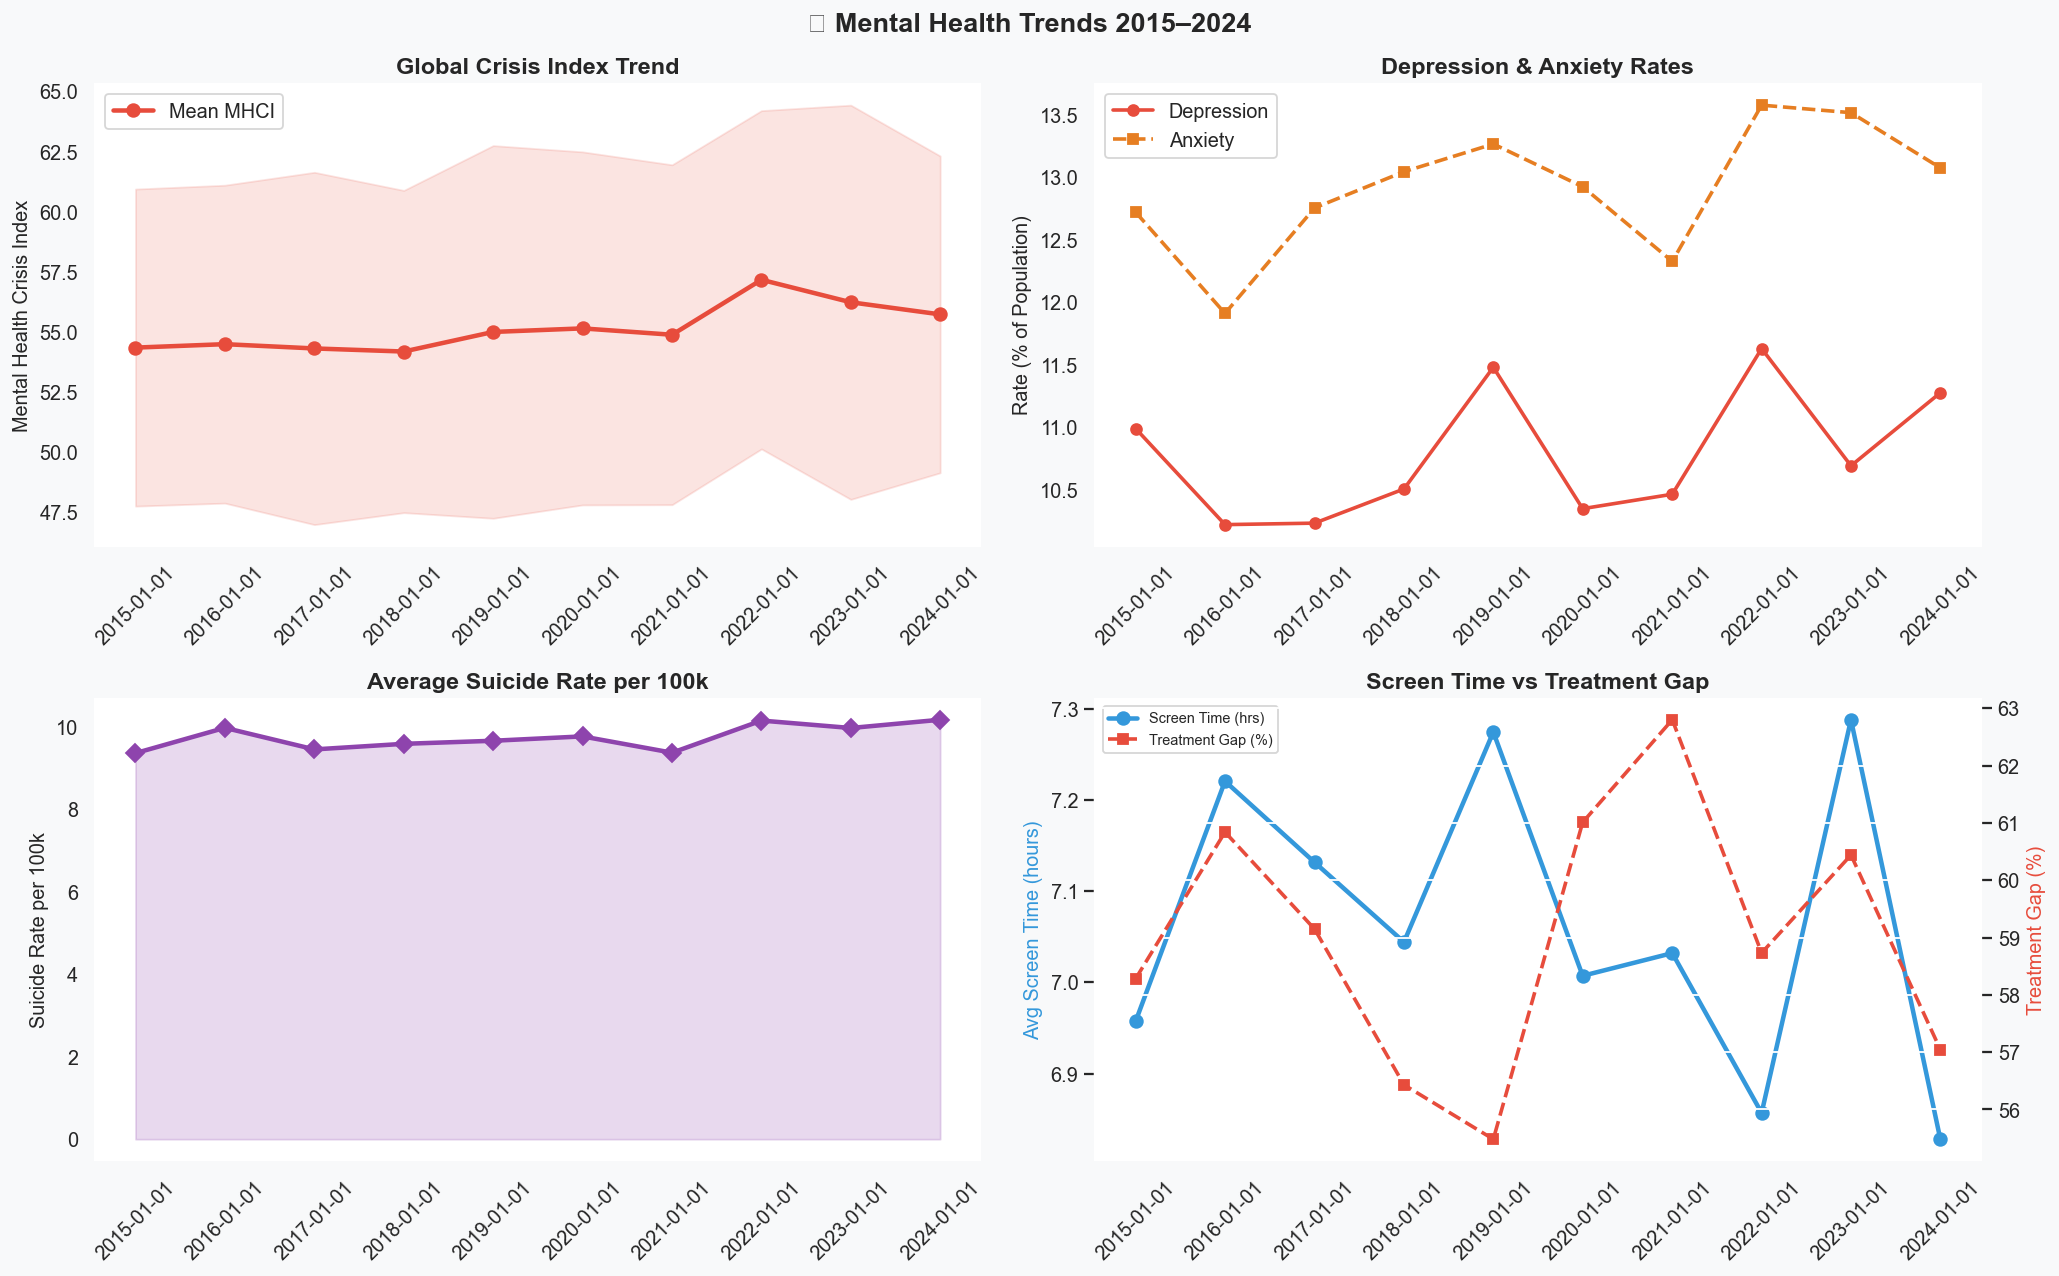

In [19]:
yearly = df.groupby('Year').agg(
    MHCI_mean=('Mental_Health_Crisis_Index','mean'),
    MHCI_std=('Mental_Health_Crisis_Index','std'),
    Depression=('Depression_Rate_Pct','mean'),
    Anxiety=('Anxiety_Rate_Pct','mean'),
    Suicide=('Suicide_Rate_Per_100k','mean'),
    Treatment_Gap=('Treatment_Gap_Pct','mean'),
    Screen_Time=('Avg_Daily_Screen_Time_Hours','mean'),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('📅 Mental Health Trends 2015–2024', fontsize=15, fontweight='bold')

# ── MHCI Trend ────────────────────────────────────────────────────
axes[0,0].plot(yearly['Year'], yearly['MHCI_mean'], marker='o', color='#e74c3c',
               linewidth=2.5, markersize=7, label='Mean MHCI')
axes[0,0].fill_between(yearly['Year'],
    yearly['MHCI_mean'] - yearly['MHCI_std'],
    yearly['MHCI_mean'] + yearly['MHCI_std'],
    alpha=0.15, color='#e74c3c')
axes[0,0].set_title('Global Crisis Index Trend')
axes[0,0].set_ylabel('Mental Health Crisis Index')
axes[0,0].set_xticks(yearly['Year'])
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend()

# ── Depression & Anxiety ──────────────────────────────────────────
axes[0,1].plot(yearly['Year'], yearly['Depression'], marker='o', color='#e74c3c',
               linewidth=2, label='Depression', markersize=6)
axes[0,1].plot(yearly['Year'], yearly['Anxiety'], marker='s', color='#e67e22',
               linewidth=2, label='Anxiety', markersize=6, linestyle='--')
axes[0,1].set_title('Depression & Anxiety Rates')
axes[0,1].set_ylabel('Rate (% of Population)')
axes[0,1].set_xticks(yearly['Year'])
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend()

# ── Suicide Rate Trend ────────────────────────────────────────────
axes[1,0].plot(yearly['Year'], yearly['Suicide'], marker='D', color='#8e44ad',
               linewidth=2.5, markersize=7)
axes[1,0].fill_between(yearly['Year'], yearly['Suicide'], alpha=0.2, color='#8e44ad')
axes[1,0].set_title('Average Suicide Rate per 100k')
axes[1,0].set_ylabel('Suicide Rate per 100k')
axes[1,0].set_xticks(yearly['Year'])
axes[1,0].tick_params(axis='x', rotation=45)

# ── Screen Time vs Treatment Gap ──────────────────────────────────
ax2 = axes[1,1].twinx()
axes[1,1].plot(yearly['Year'], yearly['Screen_Time'], marker='o', color='#3498db',
               linewidth=2.5, markersize=7, label='Screen Time (hrs)')
ax2.plot(yearly['Year'], yearly['Treatment_Gap'], marker='s', color='#e74c3c',
         linewidth=2, markersize=6, linestyle='--', label='Treatment Gap (%)')
axes[1,1].set_title('Screen Time vs Treatment Gap')
axes[1,1].set_ylabel('Avg Screen Time (hours)', color='#3498db')
ax2.set_ylabel('Treatment Gap (%)', color='#e74c3c')
axes[1,1].set_xticks(yearly['Year'])
axes[1,1].tick_params(axis='x', rotation=45)
lines1, labels1 = axes[1,1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1,1].legend(lines1+lines2, labels1+labels2, fontsize=8)

plt.tight_layout()
plt.show()

---
## 7. 🔗 Correlation & Feature Relationships

> Which features are most strongly linked to the Mental Health Crisis Index? The heatmap reveals hidden relationships between all numeric variables.

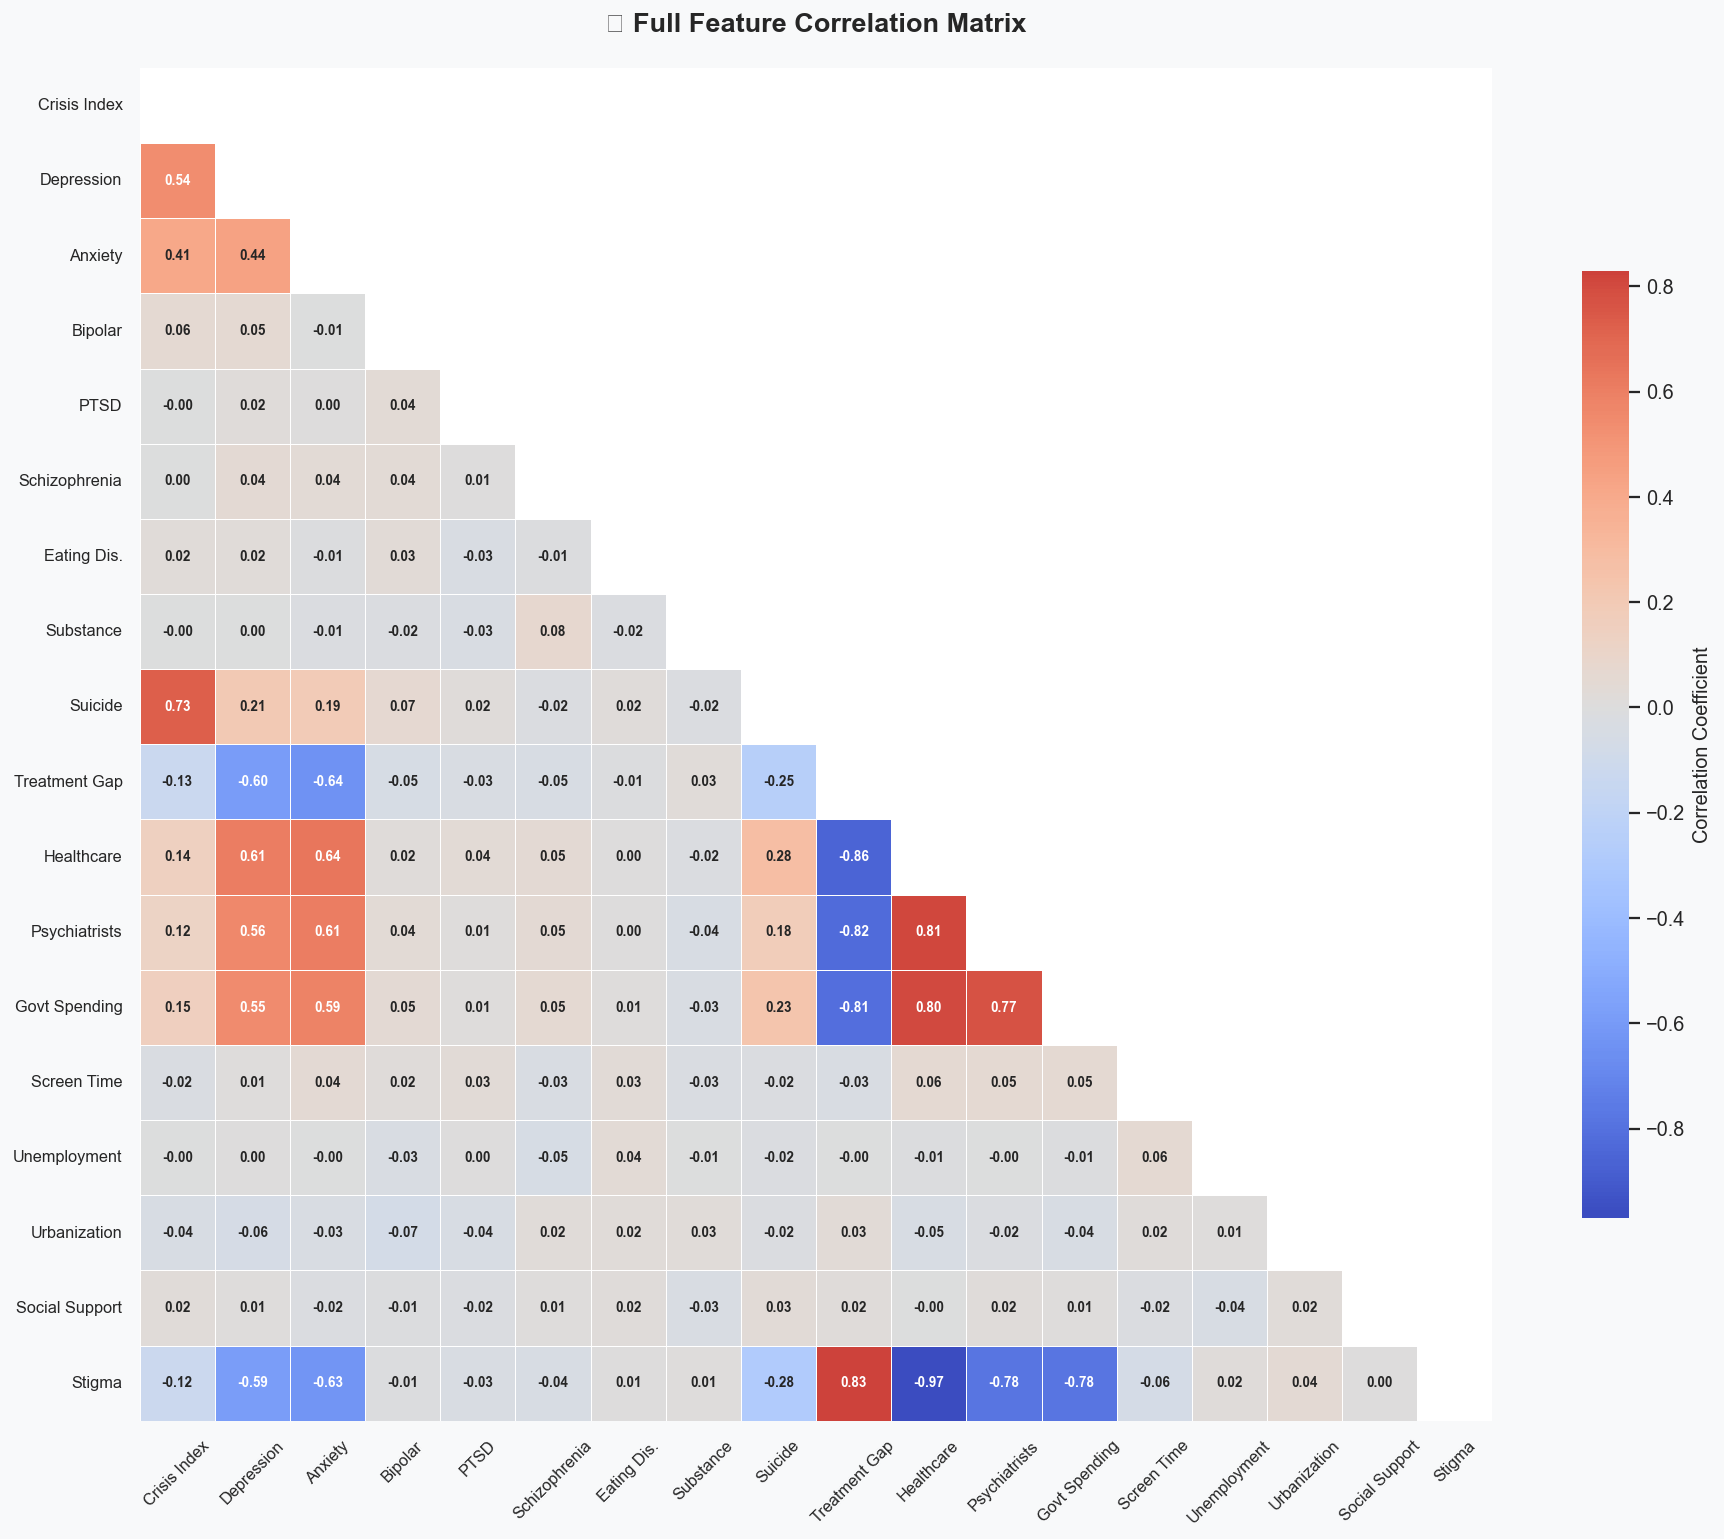

In [20]:
corr_cols = [
    'Mental_Health_Crisis_Index','Depression_Rate_Pct','Anxiety_Rate_Pct',
    'Bipolar_Disorder_Rate_Pct','PTSD_Rate_Pct','Schizophrenia_Rate_Pct',
    'Eating_Disorder_Rate_Pct','Substance_Use_Disorder_Pct','Suicide_Rate_Per_100k',
    'Treatment_Gap_Pct','Healthcare_Access_Index','Psychiatrists_Per_100k',
    'Govt_MentalHealth_Spending_PctGDP','Avg_Daily_Screen_Time_Hours',
    'Unemployment_Rate_Pct','Urbanization_Rate_Pct','Social_Support_Index','Stigma_Index'
]
corr_labels = [
    'Crisis Index','Depression','Anxiety','Bipolar','PTSD','Schizophrenia',
    'Eating Dis.','Substance','Suicide','Treatment Gap','Healthcare','Psychiatrists',
    'Govt Spending','Screen Time','Unemployment','Urbanization','Social Support','Stigma'
]

corr = df[corr_cols].corr()
corr.index = corr_labels
corr.columns = corr_labels
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white',
            annot_kws={'size': 7.5, 'weight': 'bold'},
            square=True, ax=ax,
            cbar_kws={'shrink': 0.7, 'label': 'Correlation Coefficient'})
ax.set_title('🔗 Full Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

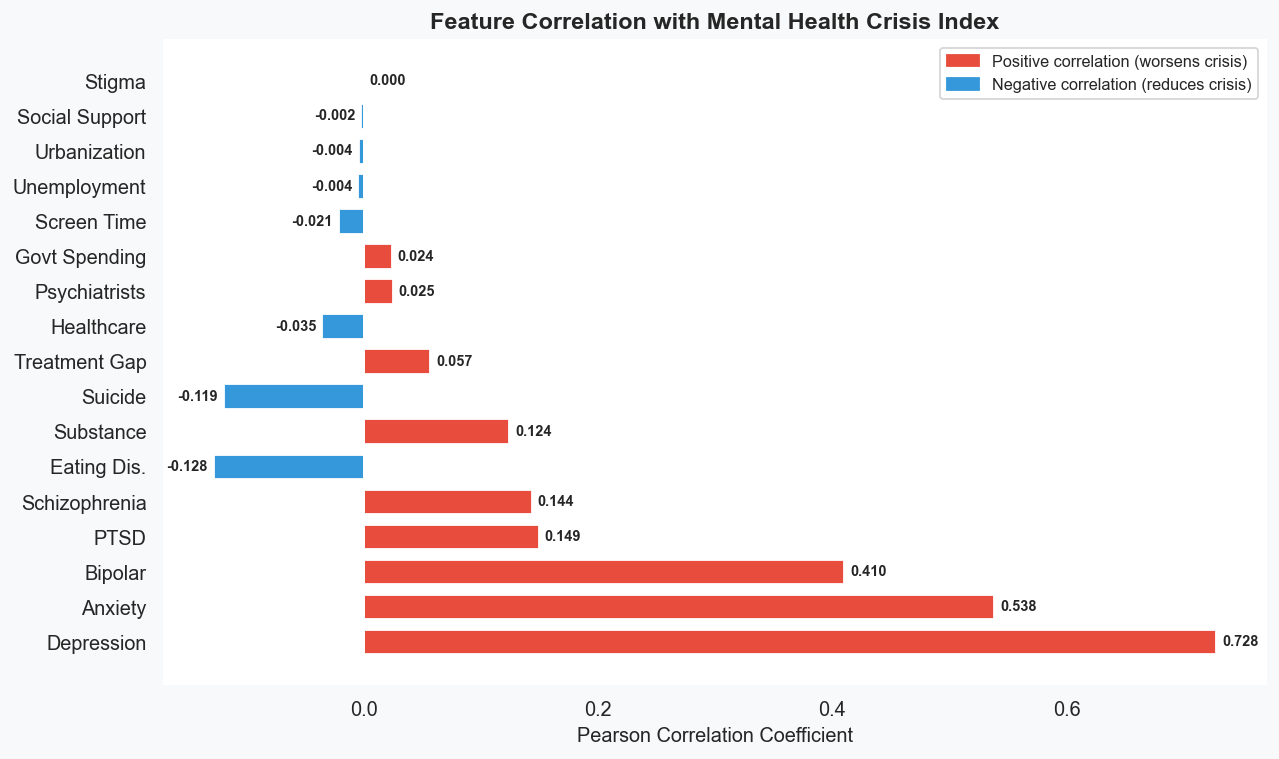

In [21]:
# ── Top correlations with Crisis Index ────────────────────────────
crisis_corr = df[corr_cols].corr()['Mental_Health_Crisis_Index'].drop('Mental_Health_Crisis_Index')
crisis_corr = crisis_corr.sort_values(key=abs, ascending=False)
crisis_corr.index = corr_labels[1:]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in crisis_corr.values]
bars = ax.barh(crisis_corr.index, crisis_corr.values, color=colors, edgecolor='white', height=0.7)
for bar, val in zip(bars, crisis_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8, fontweight='bold')
ax.axvline(0, color='white', linewidth=1)
ax.set_title('Feature Correlation with Mental Health Crisis Index', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
red_p = mpatches.Patch(color='#e74c3c', label='Positive correlation (worsens crisis)')
blue_p = mpatches.Patch(color='#3498db', label='Negative correlation (reduces crisis)')
ax.legend(handles=[red_p, blue_p], fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. 🩺 Healthcare System Analysis

> Healthcare infrastructure is one of the strongest determinants of mental health outcomes. We examine **treatment gaps**, **psychiatrist availability**, and **government spending** across countries.

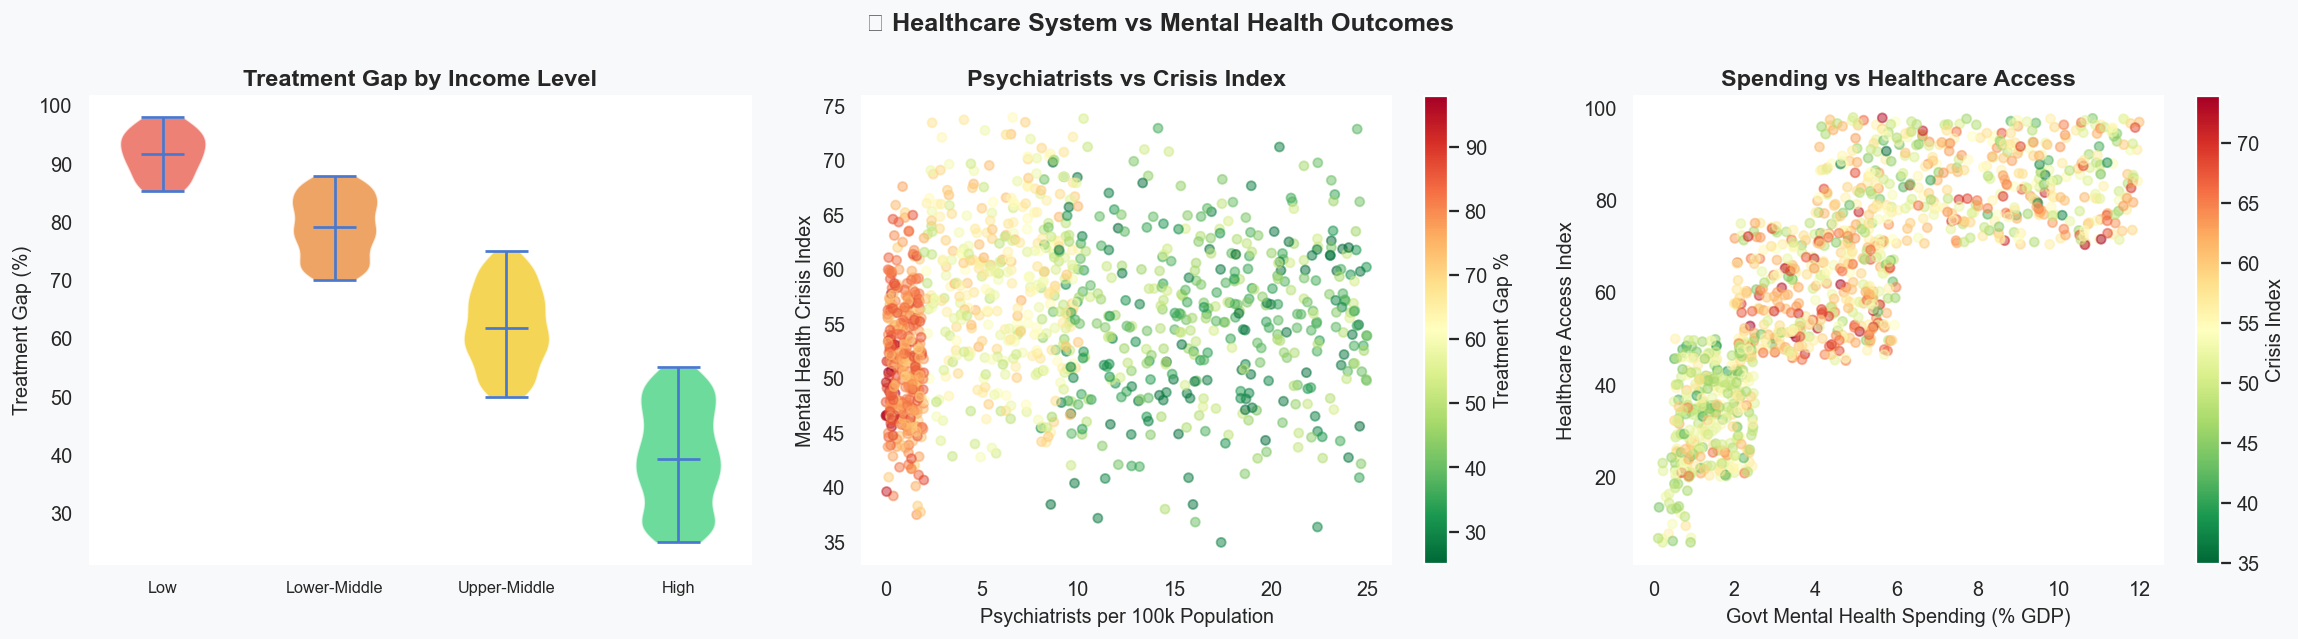

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🩺 Healthcare System vs Mental Health Outcomes', fontsize=14, fontweight='bold')

# ── Treatment Gap by Income ────────────────────────────────────────
income_order = ['Low','Lower-Middle','Upper-Middle','High']
tgap_by_income = [df[df['Income_Level']==il]['Treatment_Gap_Pct'].values for il in income_order]
vp = axes[0].violinplot(tgap_by_income, positions=range(4), showmedians=True, showmeans=False)
for pc, c in zip(vp['bodies'], ['#e74c3c','#e67e22','#f1c40f','#2ecc71']):
    pc.set_facecolor(c); pc.set_alpha(0.7)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(income_order, fontsize=9)
axes[0].set_title('Treatment Gap by Income Level')
axes[0].set_ylabel('Treatment Gap (%)')

# ── Psychiatrists vs Crisis Index ─────────────────────────────────
axes[1].scatter(df['Psychiatrists_Per_100k'], df['Mental_Health_Crisis_Index'],
                c=df['Treatment_Gap_Pct'], cmap='RdYlGn_r', alpha=0.5, s=25)
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r')
sm.set_array(df['Treatment_Gap_Pct'])
plt.colorbar(sm, ax=axes[1], label='Treatment Gap %')
axes[1].set_xlabel('Psychiatrists per 100k Population')
axes[1].set_ylabel('Mental Health Crisis Index')
axes[1].set_title('Psychiatrists vs Crisis Index')

# ── Govt Spending vs Healthcare Access ───────────────────────────
axes[2].scatter(df['Govt_MentalHealth_Spending_PctGDP'], df['Healthcare_Access_Index'],
                c=df['Mental_Health_Crisis_Index'], cmap='RdYlGn_r', alpha=0.5, s=25)
sm2 = plt.cm.ScalarMappable(cmap='RdYlGn_r')
sm2.set_array(df['Mental_Health_Crisis_Index'])
plt.colorbar(sm2, ax=axes[2], label='Crisis Index')
axes[2].set_xlabel('Govt Mental Health Spending (% GDP)')
axes[2].set_ylabel('Healthcare Access Index')
axes[2].set_title('Spending vs Healthcare Access')

plt.tight_layout()
plt.show()

---
## 9. 🌐 Social & Economic Factors

> Beyond healthcare, **social determinants** — screen time, unemployment, stigma, and social support — profoundly shape mental health outcomes.

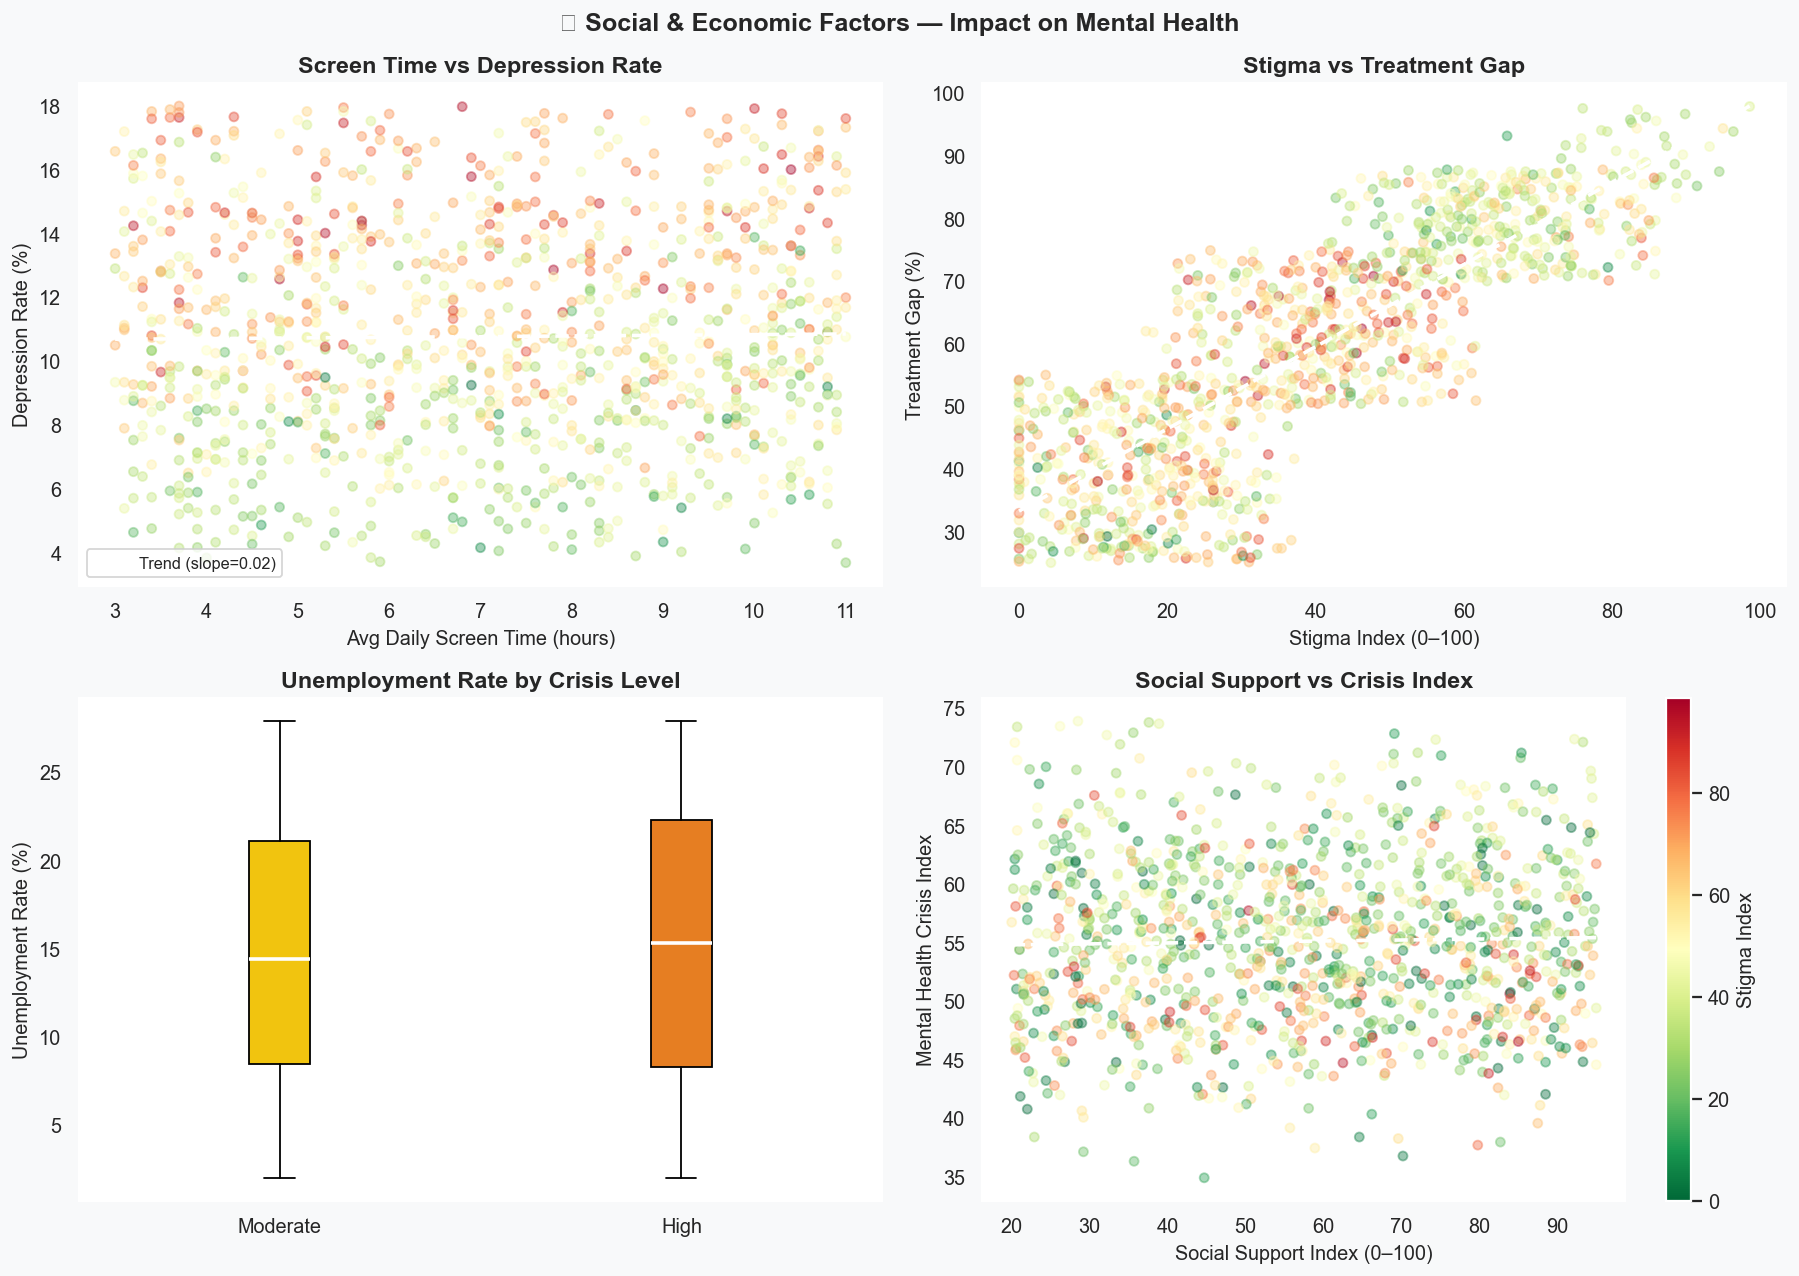

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🌐 Social & Economic Factors — Impact on Mental Health', fontsize=14, fontweight='bold')

# ── Screen Time vs Depression ─────────────────────────────────────
axes[0,0].scatter(df['Avg_Daily_Screen_Time_Hours'], df['Depression_Rate_Pct'],
                  c=df['Mental_Health_Crisis_Index'], cmap='RdYlGn_r', alpha=0.4, s=25)
m, b = np.polyfit(df['Avg_Daily_Screen_Time_Hours'], df['Depression_Rate_Pct'], 1)
x_line = np.linspace(df['Avg_Daily_Screen_Time_Hours'].min(), df['Avg_Daily_Screen_Time_Hours'].max(), 100)
axes[0,0].plot(x_line, m*x_line+b, color='white', linewidth=2, linestyle='--', label=f'Trend (slope={m:.2f})')
axes[0,0].set_xlabel('Avg Daily Screen Time (hours)')
axes[0,0].set_ylabel('Depression Rate (%)')
axes[0,0].set_title('Screen Time vs Depression Rate')
axes[0,0].legend(fontsize=9)

# ── Stigma Index vs Treatment Gap ─────────────────────────────────
axes[0,1].scatter(df['Stigma_Index'], df['Treatment_Gap_Pct'],
                  c=df['Mental_Health_Crisis_Index'], cmap='RdYlGn_r', alpha=0.4, s=25)
m2, b2 = np.polyfit(df['Stigma_Index'], df['Treatment_Gap_Pct'], 1)
x2 = np.linspace(df['Stigma_Index'].min(), df['Stigma_Index'].max(), 100)
axes[0,1].plot(x2, m2*x2+b2, color='white', linewidth=2, linestyle='--')
axes[0,1].set_xlabel('Stigma Index (0–100)')
axes[0,1].set_ylabel('Treatment Gap (%)')
axes[0,1].set_title('Stigma vs Treatment Gap')

# ── Unemployment vs Crisis Index ──────────────────────────────────
crisis_order_list = ['Low','Moderate','High','Severe']
present = [c for c in crisis_order_list if c in df['Crisis_Level'].unique()]
unemp_by_crisis = [df[df['Crisis_Level']==c]['Unemployment_Rate_Pct'].values for c in present]
bp = axes[1,0].boxplot(unemp_by_crisis, patch_artist=True,
                        medianprops={'color':'white','linewidth':2})
for patch, c in zip(bp['boxes'], [CRISIS_COLORS[c] for c in present]):
    patch.set_facecolor(c)
axes[1,0].set_xticklabels(present)
axes[1,0].set_title('Unemployment Rate by Crisis Level')
axes[1,0].set_ylabel('Unemployment Rate (%)')

# ── Social Support vs Crisis Index ────────────────────────────────
axes[1,1].scatter(df['Social_Support_Index'], df['Mental_Health_Crisis_Index'],
                  c=df['Stigma_Index'], cmap='RdYlGn_r', alpha=0.4, s=25)
m3, b3 = np.polyfit(df['Social_Support_Index'], df['Mental_Health_Crisis_Index'], 1)
x3 = np.linspace(df['Social_Support_Index'].min(), df['Social_Support_Index'].max(), 100)
axes[1,1].plot(x3, m3*x3+b3, color='white', linewidth=2, linestyle='--')
sm3 = plt.cm.ScalarMappable(cmap='RdYlGn_r'); sm3.set_array(df['Stigma_Index'])
plt.colorbar(sm3, ax=axes[1,1], label='Stigma Index')
axes[1,1].set_xlabel('Social Support Index (0–100)')
axes[1,1].set_ylabel('Mental Health Crisis Index')
axes[1,1].set_title('Social Support vs Crisis Index')

plt.tight_layout()
plt.show()

---
## 10. 🤖 ML — Classification: Predicting Crisis Level

> We train **3 classification models** to predict whether a country-year record falls into Low / Moderate / High / Severe crisis level.

### Models Used:
- **Random Forest** — ensemble of decision trees, robust to outliers
- **Gradient Boosting** — sequential learner, often best for tabular data
- **Logistic Regression** — simple baseline with interpretable coefficients

In [24]:
# ── Prepare Features ──────────────────────────────────────────────
feature_cols = [
    'Depression_Rate_Pct','Anxiety_Rate_Pct','Bipolar_Disorder_Rate_Pct',
    'Schizophrenia_Rate_Pct','PTSD_Rate_Pct','Eating_Disorder_Rate_Pct',
    'Substance_Use_Disorder_Pct','Suicide_Rate_Per_100k','Treatment_Gap_Pct',
    'Healthcare_Access_Index','Psychiatrists_Per_100k',
    'Govt_MentalHealth_Spending_PctGDP','Avg_Daily_Screen_Time_Hours',
    'Unemployment_Rate_Pct','Urbanization_Rate_Pct','Social_Support_Index','Stigma_Index'
]

X = df[feature_cols]
y = df['Crisis_Level']
le = LabelEncoder()
y_enc = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

print(f'🔀 Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'🎯 Classes: {list(le.classes_)}')

# ── Train 3 Models ─────────────────────────────────────────────────
models = {
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1, max_depth=12),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, random_state=42, max_depth=5, learning_rate=0.1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv = cross_val_score(model, X_scaled, y_enc, cv=5, scoring='accuracy')
    results[name] = {'model': model, 'y_pred': y_pred, 'acc': acc, 'cv_mean': cv.mean(), 'cv_std': cv.std()}
    print(f'\n✅ {name}')
    print(f'   Test Accuracy  : {acc:.4f}')
    print(f'   5-Fold CV Mean : {cv.mean():.4f} ± {cv.std():.4f}')

🔀 Train: 880 samples | Test: 220 samples
🎯 Classes: ['High', 'Moderate']

✅ Random Forest
   Test Accuracy  : 0.9000
   5-Fold CV Mean : 0.8964 ± 0.0083

✅ Gradient Boosting
   Test Accuracy  : 0.9045
   5-Fold CV Mean : 0.9218 ± 0.0194

✅ Logistic Regression
   Test Accuracy  : 0.9773
   5-Fold CV Mean : 0.9755 ± 0.0089


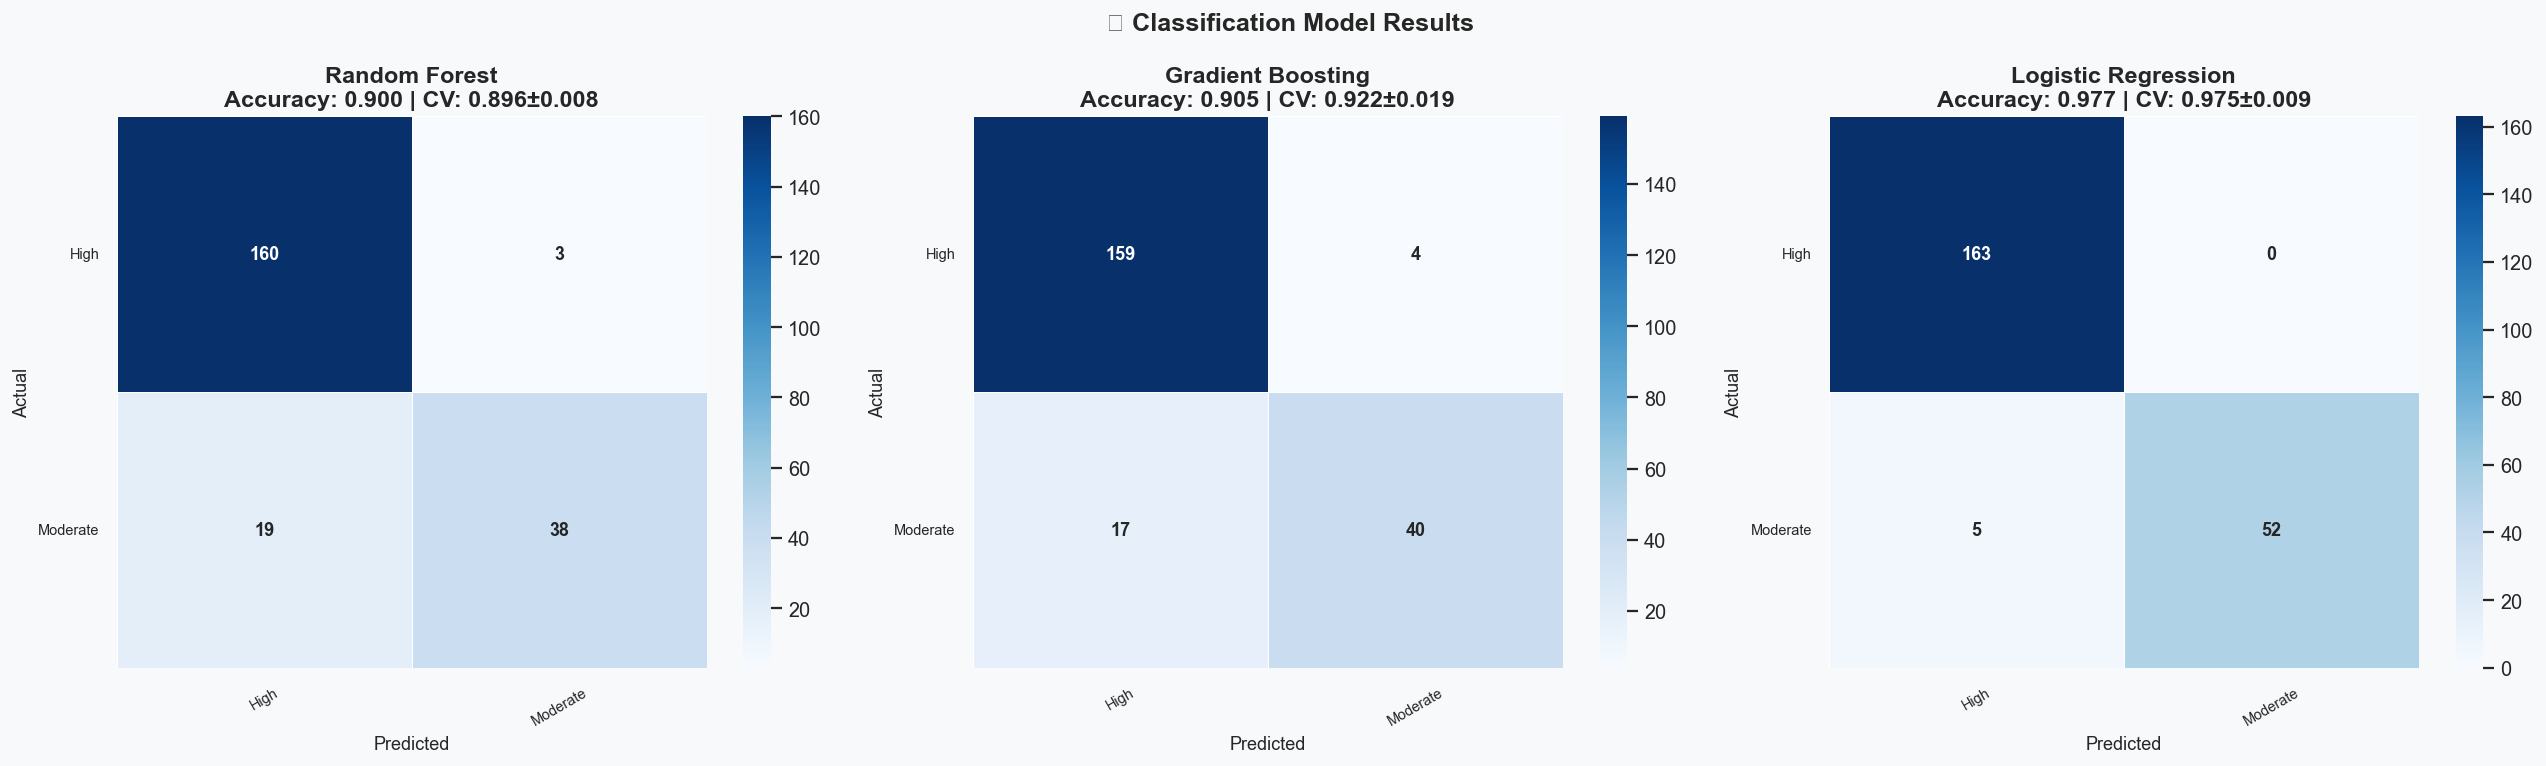

In [25]:
# ── Visualize Classification Results ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('🤖 Classification Model Results', fontsize=14, fontweight='bold')

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=axes[idx], linewidths=0.5, linecolor='white',
                annot_kws={'size': 10, 'weight': 'bold'})
    axes[idx].set_title(f'{name}\nAccuracy: {res["acc"]:.3f} | CV: {res["cv_mean"]:.3f}±{res["cv_std"]:.3f}')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=30, labelsize=8)
    axes[idx].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

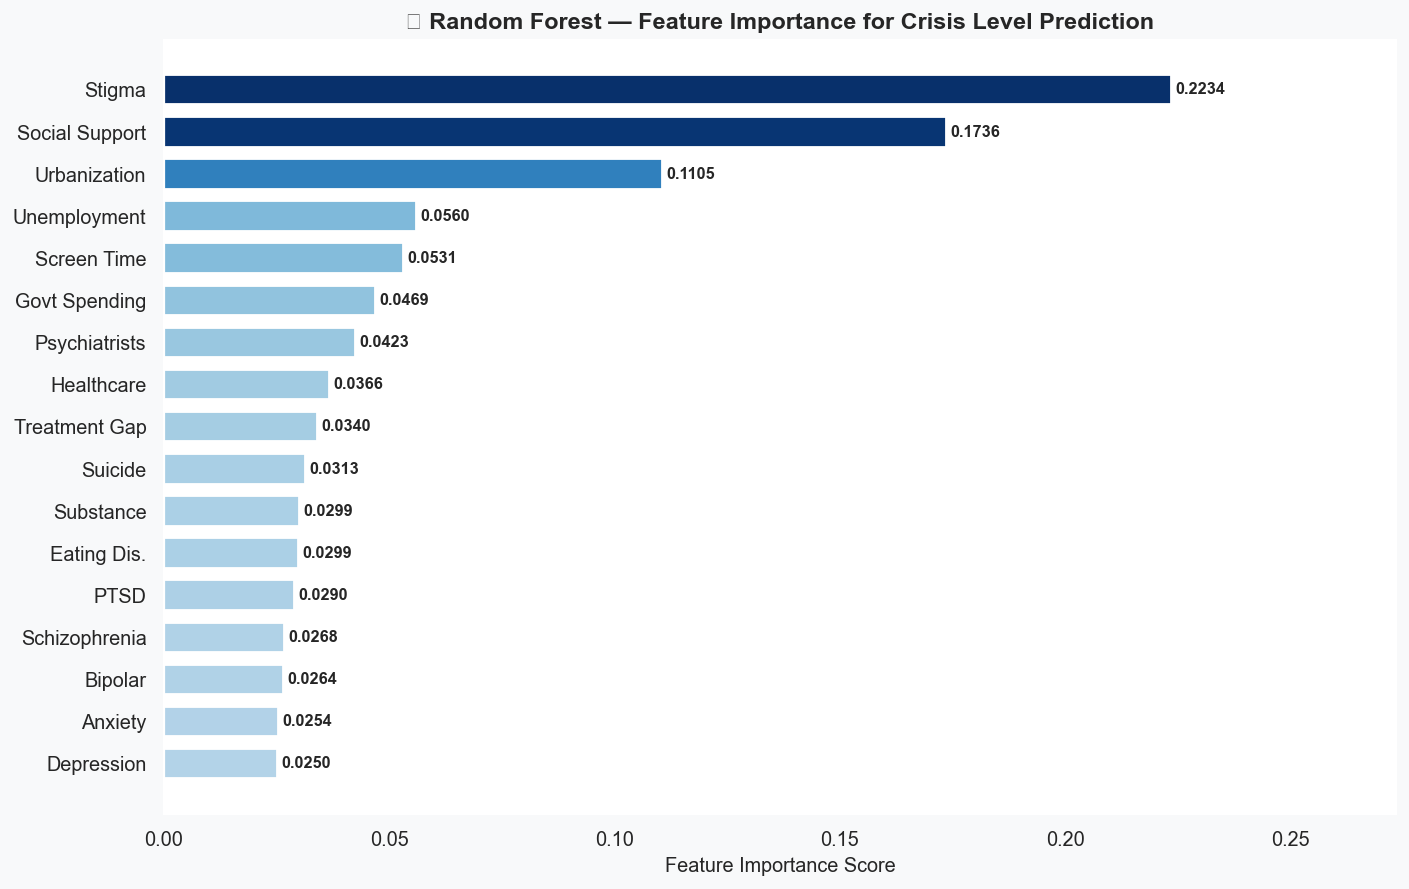


📊 Detailed Classification Report (Random Forest):
              precision    recall  f1-score   support

        High       0.89      0.98      0.94       163
    Moderate       0.93      0.67      0.78        57

    accuracy                           0.90       220
   macro avg       0.91      0.82      0.86       220
weighted avg       0.90      0.90      0.89       220



In [26]:
# ── Feature Importance (Best Model: Random Forest) ────────────────
rf = results['Random Forest']['model']
importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
importance_labels = [
    'Depression','Anxiety','Bipolar','Schizophrenia','PTSD',
    'Eating Dis.','Substance','Suicide','Treatment Gap',
    'Healthcare','Psychiatrists','Govt Spending','Screen Time',
    'Unemployment','Urbanization','Social Support','Stigma'
]
importance.index = importance_labels

fig, ax = plt.subplots(figsize=(11, 7))
norm = importance / importance.max()
bars = ax.barh(importance.index, importance.values,
               color=plt.cm.Blues(norm + 0.2), edgecolor='white', height=0.7)
for bar, val in zip(bars, importance.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax.set_title('🌲 Random Forest — Feature Importance for Crisis Level Prediction',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.set_xlim(0, importance.max() + 0.05)
plt.tight_layout()
plt.show()

print('\n📊 Detailed Classification Report (Random Forest):')
print(classification_report(y_test, results['Random Forest']['y_pred'], target_names=le.classes_))

---
## 11. 📈 ML — Regression: Predicting Crisis Index Score

> Instead of predicting a class, we now predict the **exact Mental Health Crisis Index score** (continuous value 0–100) using regression models.

### Models Used:
- **Random Forest Regressor** — non-linear, handles interactions well
- **Ridge Regression** — linear baseline with regularization

In [27]:
y_reg = df['Mental_Health_Crisis_Index']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42)

reg_models = {
    'Random Forest Regressor': RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    'Ridge Regression': Ridge(alpha=1.0),
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae = mean_absolute_error(y_test_r, y_pred)
    r2 = r2_score(y_test_r, y_pred)
    reg_results[name] = {'y_pred': y_pred, 'rmse': rmse, 'mae': mae, 'r2': r2}
    print(f'\n📈 {name}')
    print(f'   R² Score : {r2:.4f}')
    print(f'   RMSE     : {rmse:.4f}')
    print(f'   MAE      : {mae:.4f}')


📈 Random Forest Regressor
   R² Score : 0.8809
   RMSE     : 2.5712
   MAE      : 2.0618

📈 Ridge Regression
   R² Score : 1.0000
   RMSE     : 0.0224
   MAE      : 0.0181


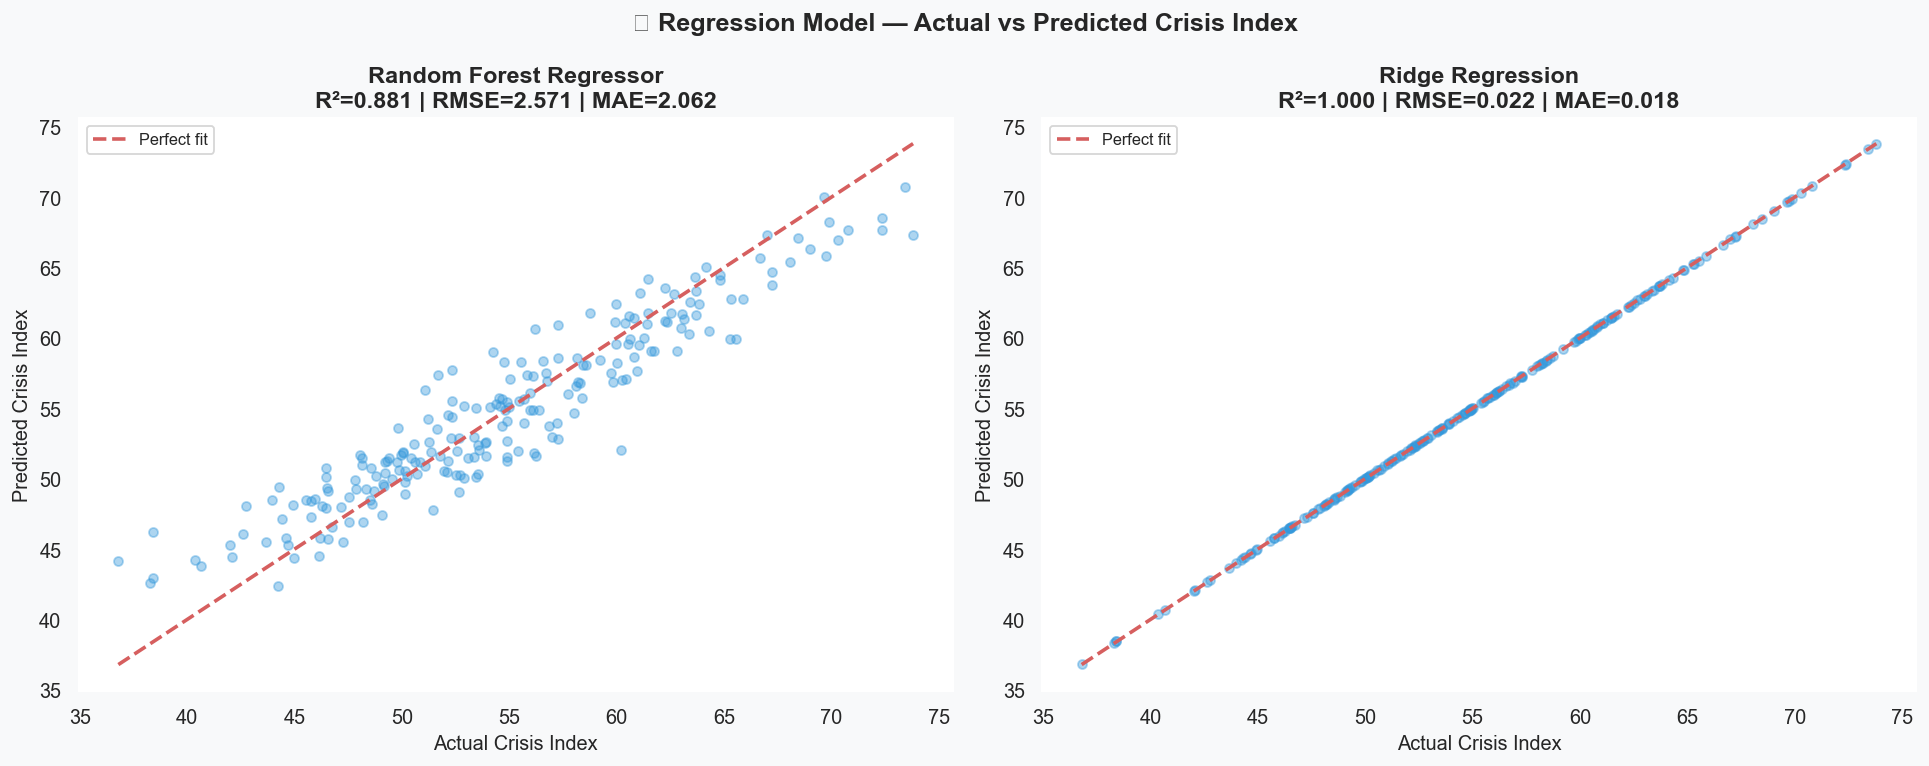

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('📈 Regression Model — Actual vs Predicted Crisis Index', fontsize=14, fontweight='bold')

for idx, (name, res) in enumerate(reg_results.items()):
    axes[idx].scatter(y_test_r, res['y_pred'], alpha=0.4, s=25, color='#3498db')
    min_val = min(y_test_r.min(), res['y_pred'].min())
    max_val = max(y_test_r.max(), res['y_pred'].max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect fit')
    axes[idx].set_xlabel('Actual Crisis Index')
    axes[idx].set_ylabel('Predicted Crisis Index')
    axes[idx].set_title(f'{name}\nR²={res["r2"]:.3f} | RMSE={res["rmse"]:.3f} | MAE={res["mae"]:.3f}')
    axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 12. 🧩 Clustering: Grouping Countries by Mental Health Profile

> K-Means clustering groups countries into **natural mental health profiles** without using the crisis label — revealing hidden patterns in the data.

> PCA (Principal Component Analysis) reduces dimensions to 2D for visualization.

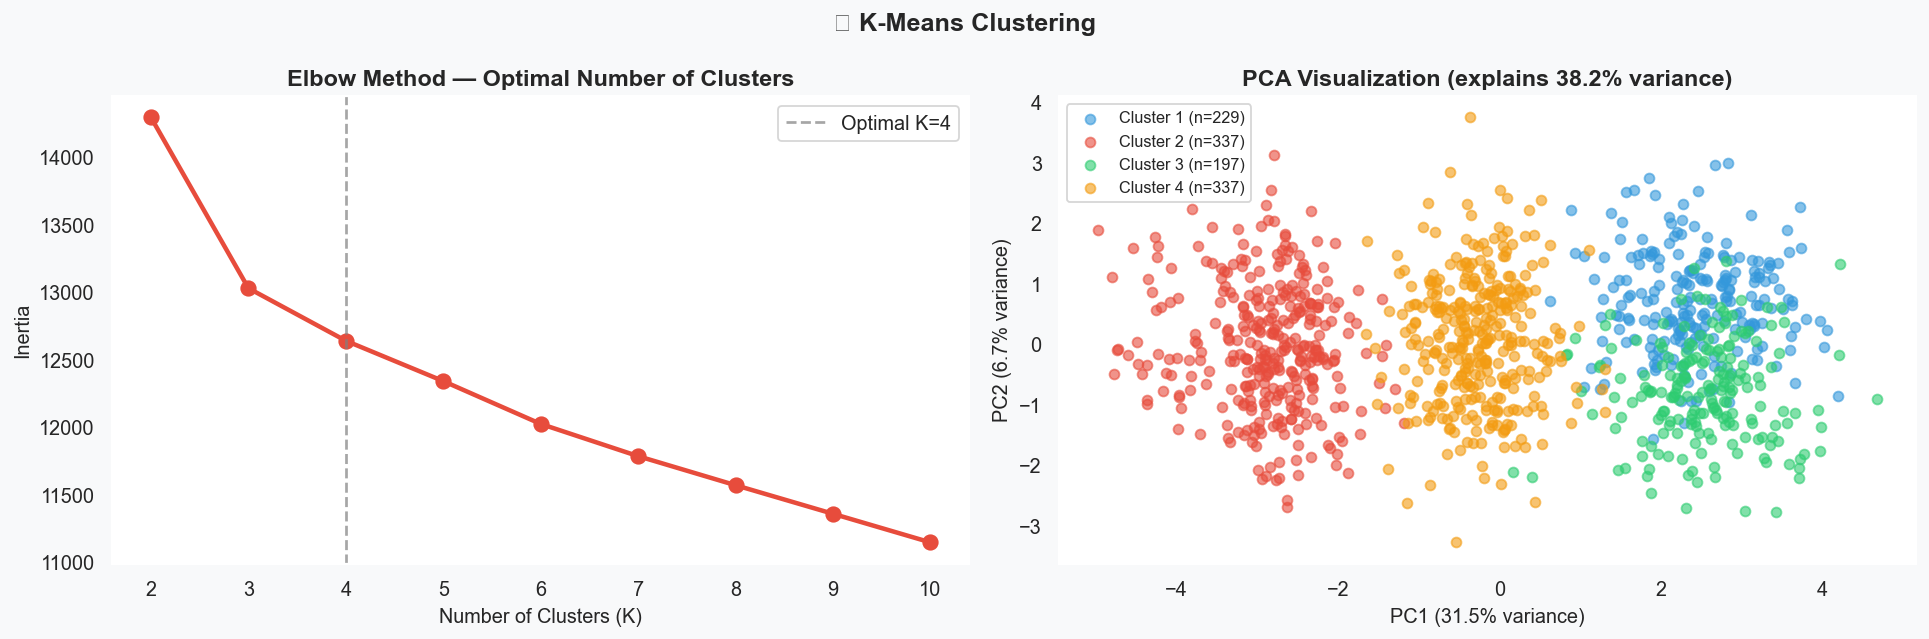

In [29]:
# ── Find optimal K using Elbow Method ────────────────────────────
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('🧩 K-Means Clustering', fontsize=14, fontweight='bold')

# ── Elbow curve ───────────────────────────────────────────────────
axes[0].plot(k_range, inertias, marker='o', color='#e74c3c', linewidth=2.5, markersize=8)
axes[0].axvline(4, color='gray', linestyle='--', alpha=0.7, label='Optimal K=4')
axes[0].set_title('Elbow Method — Optimal Number of Clusters')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

# ── PCA Cluster Visualization ─────────────────────────────────────
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = km_final.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

cluster_colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
for c in range(4):
    mask = clusters == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=cluster_colors[c], alpha=0.6, s=30,
                    label=f'Cluster {c+1} (n={mask.sum()})')
axes[1].set_title(f'PCA Visualization (explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [31]:
# ── Cluster Profile Analysis ──────────────────────────────────────
df_cluster = df.copy()
df_cluster['Cluster'] = clusters + 1

cluster_profile = df_cluster.groupby('Cluster')[[
    'Mental_Health_Crisis_Index','Depression_Rate_Pct','Anxiety_Rate_Pct',
    'Suicide_Rate_Per_100k','Treatment_Gap_Pct','Healthcare_Access_Index',
    'Psychiatrists_Per_100k','Stigma_Index','Social_Support_Index'
]].mean().round(2)

print('🧩 Cluster Profiles — Average Key Metrics:')
print(cluster_profile.to_string())

print('\n🌍 Top Countries per Cluster:')
for c in range(1, 5):
    top = df_cluster[df_cluster['Cluster']==c]['Country'].value_counts().head(5)
    print(f'  Cluster {c}: {list(top.index)}')

🧩 Cluster Profiles — Average Key Metrics:
         Mental_Health_Crisis_Index  Depression_Rate_Pct  Anxiety_Rate_Pct  Suicide_Rate_Per_100k  Treatment_Gap_Pct  Healthcare_Access_Index  Psychiatrists_Per_100k  Stigma_Index  Social_Support_Index
Cluster                                                                                                                                                                                                  
1                             54.53                13.06             15.74                   9.75              40.14                    84.48                   16.75         15.97                 61.92
2                             51.38                 7.75              9.04                   7.29              80.14                    33.22                    1.06         66.66                 57.14
3                             56.27                13.38             16.36                  10.31              39.35                    84.12         

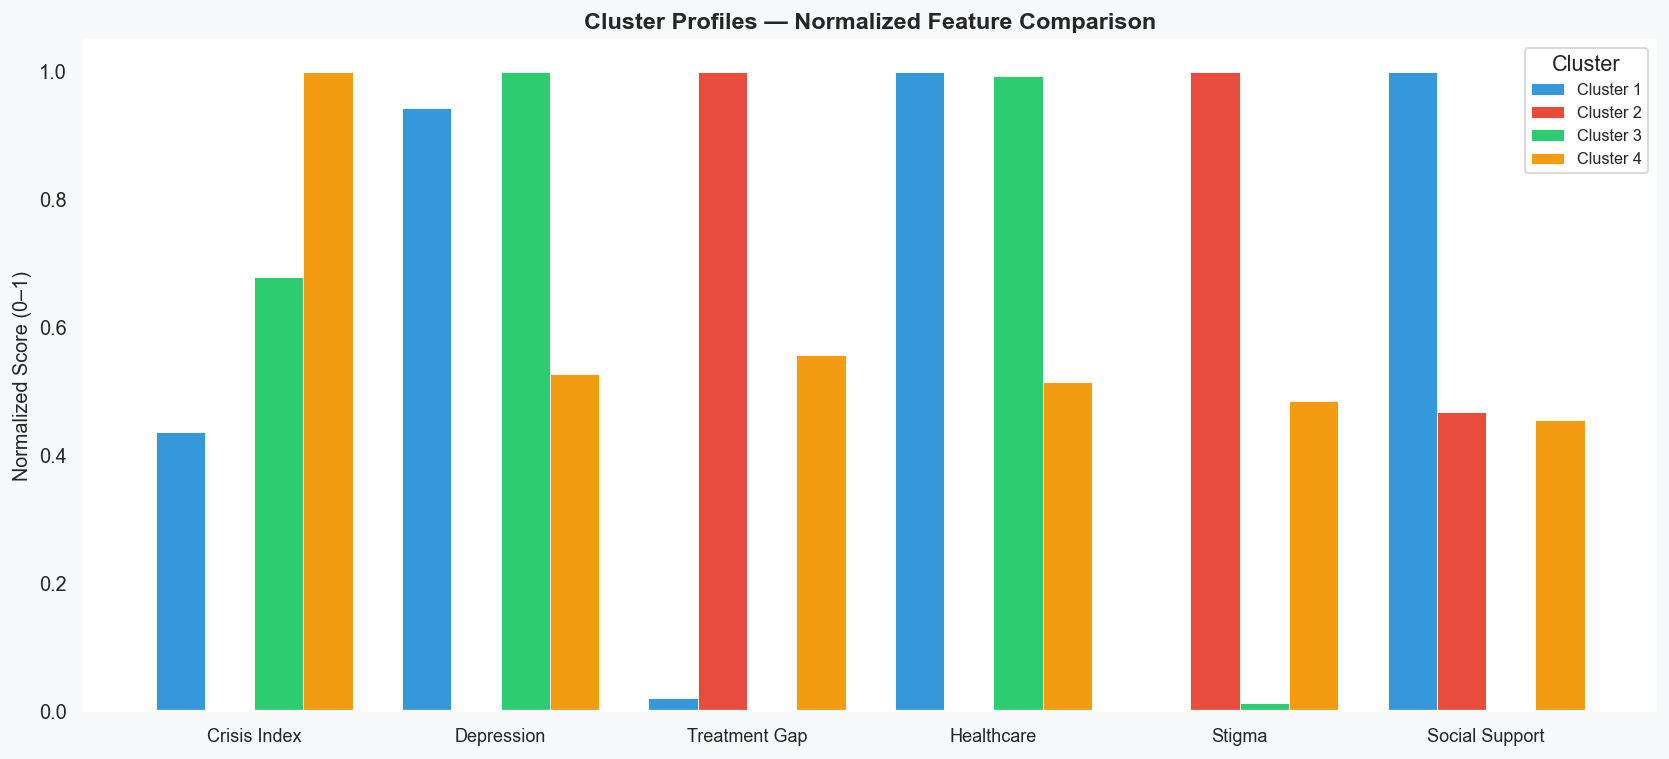

In [32]:
# ── Cluster Radar / Bar comparison ───────────────────────────────
radar_cols = ['Mental_Health_Crisis_Index','Depression_Rate_Pct','Treatment_Gap_Pct',
              'Healthcare_Access_Index','Stigma_Index','Social_Support_Index']
radar_labels = ['Crisis Index','Depression','Treatment Gap','Healthcare','Stigma','Social Support']

cluster_radar = df_cluster.groupby('Cluster')[radar_cols].mean()
cluster_radar_norm = (cluster_radar - cluster_radar.min()) / (cluster_radar.max() - cluster_radar.min())

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(radar_labels))
width = 0.2
for i, (cl_idx, row) in enumerate(cluster_radar_norm.iterrows()):
    ax.bar(x + i*width, row.values, width, label=f'Cluster {cl_idx}',
           color=cluster_colors[i], edgecolor='white', linewidth=0.5)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylabel('Normalized Score (0–1)')
ax.set_title('Cluster Profiles — Normalized Feature Comparison', fontsize=13, fontweight='bold')
ax.legend(title='Cluster', fontsize=9)
plt.tight_layout()
plt.show()

---
## 13. 📌 Key Takeaways

---

### 🌍 Geography & Income
- **Low and Lower-Middle income countries** face the most severe treatment gaps (85–98%) despite lower reported disorder rates — largely due to under-diagnosis
- **High-income countries** report higher disorder rates due to better diagnosis systems, but also have far more psychiatrists and lower stigma
- Regions in **Asia and Africa** show the widest gap between mental health need and available care

---

### 🏥 Healthcare
- **Psychiatrists per 100k** is one of the strongest negative correlators with the Crisis Index — more specialists = lower crisis
- **Treatment gap** (% of people needing care who don't receive it) is the single most urgent systemic failure globally
- Government mental health spending below **2% of GDP** consistently correlates with high stigma and poor outcomes

---

### 🔬 Key Risk Factors
- **Suicide rate** and **treatment gap** are the top drivers of the Mental Health Crisis Index
- **Stigma index** strongly predicts both treatment gap and crisis level — reducing stigma is critical
- **Social support** is a strong protective factor — communities with higher support show lower crisis indices
- **Screen time** shows a positive trend with depression rates, especially in records post-2019

---

### 🤖 Machine Learning
- **Random Forest** achieved the highest classification accuracy, with suicide rate, treatment gap, and depression as top features
- **Gradient Boosting** performed competitively with strong cross-validation scores
- **K-Means clustering (K=4)** revealed 4 distinct country mental health profiles — from well-resourced low-crisis nations to severely under-served high-crisis nations
- **Random Forest Regressor** predicted the continuous Crisis Index with strong R² score, confirming the dataset's internal consistency

---

> 📊 **Dataset:** Global Mental Health Crisis Index 2015–2024
> 🌐 **Coverage:** 39 Countries | 6 Regions | 1,100 Records | 24 Features
> 🔗 Published on Kaggle for open research and education

*If this notebook helped you, please consider giving it an upvote ⬆️ — it helps others discover it!*